# 02 · Doğrusal Regresyon Ailesi: Düzenlileştirme, Dayanıklı Regresyon ve Genelleştirilmiş Doğrusal Modeller (Linear Regression Family)
**Classical ML Lab** · Saf OLS'ten Endüstride Gerçekten Kullanılan Modellere

---
> **Bu notebook'ta ne öğreneceğiz?**
> `Statistic-Inference-lab/03_regression_diagnostics`'te OLS'un varsayımlarını, katsayı yorumunu ve tanısal (diagnostic) grafiklerini derinlemesine işledik. Bu notebook'ta OLS'u kısaca hatırlayıp, gerçek dünyada onun yetersiz kaldığı üç somut senaryoya ve endüstrinin bu senaryolar için geliştirdiği çözümlere odaklanıyoruz:
>
> - **Düzenlileştirme (Regularization):** Değişkenler birbirine güçlü korelasyonlu (multicollinearity) ya da değişken sayısı gözlem sayısına yaklaştığında OLS katsayıları kararsızlaşır → **Ridge (L2)**, **Lasso (L1)**, **Elastic Net**
> - **Dayanıklı (Robust) Regresyon:** Veride aykırı değerler/ölçüm hataları olduğunda OLS'un karesel kaybı bu noktalara aşırı ağırlık verir → **Huber**, **RANSAC**, **Theil-Sen**, **Quantile Regression**
> - **Genelleştirilmiş Doğrusal Modeller (GLM):** Hedef değişken sayım (count) ya da kesinlikle pozitif/çarpık ise Normal dağılım varsayımı çöker → **Poisson**, **Gamma**, **Tweedie**
>
> Her bölümü, o yöntemin **gerçekten hangi endüstride, hangi karar için** kullanıldığını göstererek işliyoruz (sigorta fiyatlandırması, denizcilik risk analizi, otomotiv/üretim kalite kontrolü) — amaç sadece formülü bilmek değil, "bu yöntemi ne zaman seçerim?" sorusuna iş hayatında cevap verebilmek.
>
> **Önkoşul:** `Statistic-Inference-lab/03_regression_diagnostics/regression_diagnostics.ipynb` (OLS temelleri, varsayımlar, tanısal grafikler), `Classical-ML-lab/01_data_prepreparation/` (encoding, ölçekleme, eksik veri)
> **Veri:** Medical Cost Personal Datasets (sigorta), Ships Damage Data (McCullagh & Nelder, 1989), Auto MPG (UCI)
> **Araçlar:** Python (`scikit-learn`, `statsmodels`), R (`glmnet`, `MASS`, `mblm`, `quantreg`, `statmod`), SQL (`DuckDB`)


---
## 1 · Genel Çerçeve: "Doğrusal Regresyon Ailesi" Ne Demek?

Bu notebook'ta göreceğimiz tüm yöntemlerin ortak bir iskeleti var: bir **doğrusal öngörücü (linear predictor)**
$$\eta = X\beta = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$
hesaplanır, sonra bu $\eta$ bir şekilde tahmine dönüştürülür. Yöntemler birbirinden üç eksende ayrılır:

| Eksen | Soru | Örnek |
|---|---|---|
| **Kayıp fonksiyonu (loss)** | Hatalar nasıl cezalandırılıyor? | Kareler toplamı (OLS) mu, mutlak değer mi, Huber'in ikisinin karışımı mı? |
| **Ceza terimi (penalty)** | Katsayı büyüklüğüne bir kısıt var mı? | Yok (OLS), L2 (Ridge), L1 (Lasso), ikisi birden (Elastic Net) |
| **Bağlantı fonksiyonu ve dağılım (link & family)** | $\eta$, ortalama tahmine nasıl dönüşüyor, hedef değişken hangi dağılıma uyuyor? | Kimlik/Normal (OLS), Log/Poisson (sayım), Log/Gamma (pozitif çarpık) |

Aşağıdaki tablo, bu notebook'ta işleyeceğimiz her yöntemi bu üç eksende konumlandırıyor — bölümler ilerledikçe bu tabloya geri dönmek faydalı olacak:

| Yöntem | Kayıp / Dağılım | Ceza | Ne zaman kullanılır (özet) |
|---|---|---|---|
| OLS | Kareler toplamı | Yok | Temiz veri, az/orta değişken, aykırı değer yok |
| Ridge | Kareler toplamı | L2 | Çoklu bağlantı (multicollinearity), tüm değişkenler tutulsun isteniyor |
| Lasso | Kareler toplamı | L1 | Çok sayıda değişken, otomatik özellik seçimi isteniyor |
| Elastic Net | Kareler toplamı | L1+L2 | Korelasyonlu değişken **grupları** var, Lasso'nun keyfi seçimi istenmiyor |
| Huber | Karesel+doğrusal karışık | Yok (istenirse eklenir) | Az sayıda orta şiddette aykırı değer |
| RANSAC | Uzlaşı kümesi (consensus) | Yok | Verinin büyük kısmı (>%50 bile olabilir) bozuk/gürültülü |
| Theil-Sen | İkili eğimlerin medyanı | Yok | Küçük/orta veri, dağılım varsayımı istenmiyor |
| Quantile Regression | Pinball loss | İsteğe bağlı L1 | Ortalama değil, belirli bir yüzdelik (persentil) tahmin edilmek isteniyor |
| Poisson GLM | Poisson | İsteğe bağlı | Hedef bir **sayım** (0, 1, 2, ...) |
| Gamma GLM | Gamma | İsteğe bağlı | Hedef **kesinlikle pozitif, sağa çarpık** sürekli değer |
| Tweedie GLM | Tweedie (bileşik Poisson-Gamma) | İsteğe bağlı | Hedef **çoğunlukla sıfır + pozitif çarpık kuyruk** |


---
## 2 · Teori — OLS Hatırlatma ve Çoklu Bağlantı (Multicollinearity) Sorunu

### 2.1 Hızlı Hatırlatma
En Küçük Kareler (Ordinary Least Squares) katsayıları, kalıntıların (residuals) kareler toplamını minimize ederek kapalı-form çözümle bulunur:
$$\hat\beta_{OLS} = \arg\min_\beta \|y - X\beta\|_2^2 = (X^\top X)^{-1} X^\top y$$
Bu çözümün geçerli/güvenilir olması için beş varsayım gerekir — **doğrusallık, gözlemlerin bağımsızlığı, sabit varyans (homoscedasticity), kalıntıların normalliği, ve $X$ sütunları arasında tam/yakın-tam çoklu bağlantı olmaması**. İlk dördünü ve tanısal (diagnostic) grafiklerini (residual vs fitted, Q-Q plot, Cook's distance, ...) `Statistic-Inference-lab/03_regression_diagnostics/regression_diagnostics.ipynb`'de detaylıca işledik — burada beşincisine, çoklu bağlantıya odaklanıyoruz çünkü Bölüm 3-5'teki düzenlileştirme yöntemlerinin **var olma sebebi tam olarak bu**.

### 2.2 Çoklu Bağlantı (Multicollinearity) ve VIF
$(X^\top X)^{-1}$'in var olabilmesi için $X^\top X$'in tersinin alınabilir olması gerekir. Bağımsız değişkenler birbirleriyle güçlü korelasyonlu olduğunda $X^\top X$ neredeyse **tekil (singular)** hâle gelir: matris tersi patlar, katsayı tahminlerinin varyansı aşırı büyür, katsayılar veri setindeki küçük değişikliklere karşı çılgınca sallanır (işaretleri bile değişebilir), ve $p$-değerleri güvenilmez hâle gelir — buna rağmen modelin **toplam tahmin gücü ($R^2$)** genelde etkilenmez, sorun katsayıların **yorumlanabilirliğinde**.

Bunu sayısallaştırmanın standart yolu **Variance Inflation Factor (VIF)**'tir — her değişken $x_j$ için, onu diğer tüm değişkenlerle regresyona sokup elde edilen $R_j^2$ üzerinden:
$$VIF_j = \frac{1}{1 - R_j^2}$$
$R_j^2 \to 1$ (yani $x_j$ diğer değişkenlerden neredeyse tam tahmin edilebiliyor) olduğunda $VIF_j \to \infty$. Pratikte $VIF_j > 5$ dikkat, $VIF_j > 10$ ciddi çoklu bağlantı işaretidir.

**Endüstride nerede kullanılır?** Saf OLS, ekonometride talep tahmini (fiyat esnekliği), A/B test sonrası etki büyüklüğü tahmini gibi **az sayıda, birbirinden bağımsız/kontrollü değişkenin** olduğu senaryolarda hâlâ standarttır. Ama örneğin **pazarlama karışımı modellemesinde (marketing mix modeling)** — TV, dijital reklam, radyo harcamalarının satışa etkisini ayrı ayrı tahmin etmeye çalıştığınızda — bu kanallara genelde aynı dönemlerde birlikte bütçe ayrılır (birbirleriyle korelasyonludur), bu da tam olarak yukarıdaki VIF patlamasına yol açar. Bölüm 3-5'teki Ridge/Lasso/Elastic Net, bu durumda OLS'un yerini alan endüstri standardı çözümlerdir.


---
## 3 · Teori — Düzenlileştirme I: Ridge Regression (L2)

Ridge, OLS'un kayıp fonksiyonuna katsayıların **karelerinin toplamı** kadar bir ceza ekler:
$$\hat\beta_{Ridge} = \arg\min_\beta \left[ \|y - X\beta\|_2^2 + \lambda \sum_{j=1}^p \beta_j^2 \right]$$
$\lambda \geq 0$ (scikit-learn'de `alpha`), cezanın şiddetini kontrol eder — $\lambda=0$ tam OLS'e, $\lambda \to \infty$ ise tüm katsayıların sıfıra (ama tam sıfır **olmadan**) yaklaşmasına karşılık gelir. Ridge'in de kapalı-form çözümü vardır:
$$\hat\beta_{Ridge} = (X^\top X + \lambda I)^{-1} X^\top y$$
$\lambda I$ terimi, $X^\top X$'e köşegen boyunca küçük bir sabit ekleyerek matrisi **her zaman tersinir** yapar — çoklu bağlantı sorununu doğrudan matematiksel olarak çözer. Bunun bedeli **yanlılık (bias)** eklemektir: Ridge katsayıları artık yansız (unbiased) değildir, ama karşılığında **varyansları çarpıcı biçimde düşer**. Bu, istatistikteki temel **yanlılık-varyans ödünleşimi (bias-variance tradeoff)**'nin doğrudan bir uygulamasıdır — az miktarda yanlılık kabul ederek çok daha kararlı (düşük varyanslı), dolayısıyla görülmemiş veride genelde daha iyi genelleyen bir model elde edilir.

Geometrik olarak Ridge, $\sum \beta_j^2 \leq t$ ile tanımlı **dairesel/küresel** bir kısıt bölgesi içinde RSS'i minimize etmeye eşdeğerdir — bu bölgenin köşesi olmadığı için katsayılar küçülür ama neredeyse hiçbir zaman **tam sıfıra** ulaşmaz.

**Endüstride nerede kullanılır?** Genomik/biyoinformatikte (gen ifadesi verisi: binlerce, çoğu birbiriyle korelasyonlu özellik, çok az örneklem — $p \gg n$), ekonometride ve az önce bahsettiğimiz pazarlama karışımı modellemesinde (korelasyonlu medya kanalları) Ridge, "tüm değişkenleri modelde tutmak istiyorum ama katsayılar patlamasın" ihtiyacının standart cevabıdır.


---
## 4 · Teori — Düzenlileştirme II: Lasso Regression (L1)

Lasso (Least Absolute Shrinkage and Selection Operator), aynı fikri **mutlak değer** cezasıyla uygular:
$$\hat\beta_{Lasso} = \arg\min_\beta \left[ \|y - X\beta\|_2^2 + \lambda \sum_{j=1}^p |\beta_j| \right]$$
Bu küçük görünen fark (kare yerine mutlak değer) büyük bir sonuç doğurur: Lasso'nun **kapalı-form çözümü yoktur** (ceza terimi $\beta_j=0$'da türevlenemez), sayısal olarak koordinat inişi (coordinate descent) veya LARS algoritmasıyla çözülür — ama karşılığında Lasso, yeterince büyük $\lambda$ için katsayıları **tam olarak sıfıra** iter, yani otomatik **özellik seçimi (feature selection)** yapar.

Geometrik olarak Lasso'nun kısıt bölgesi $\sum |\beta_j| \leq t$ ile tanımlı bir **çokyüzlü (elmas/diamond)** şeklidir — bu şeklin **köşeleri** eksenler üzerindedir, ve RSS'in eliptik kontur çizgileri bu köşelerden birine değme olasılığı yüksektir; tam da bu köşede değme, ilgili katsayının sıfırlanması demektir. Ridge'in yuvarlak bölgesinde ise böyle bir köşe olmadığı için bu sıfırlama neredeyse hiç olmaz.

**Endüstride nerede kullanılır?** Kredi skorlama/kredi risk modellemesinde bankalar genelde yüzlerce potansiyel özellik (işlem geçmişi, demografik veri, dış veri kaynakları) toplar; Lasso bunlardan **gerçekten anlamlı olanları otomatik seçer**, hem modeli yorumlanabilir kılar hem de düzenleyici (regülasyon) gereksinimler için "hangi değişkenler karara giriyor?" sorusuna net cevap verir. Genomikte biyobelirteç (biomarker) seçiminde, yüksek boyutlu finansal faktör modellerinde de aynı sebeple standarttır.


---
## 5 · Teori — Elastic Net: Ridge + Lasso Sentezi

Elastic Net, iki cezayı bir `l1_ratio` ($\alpha \in [0,1]$, scikit-learn'de bu isimle) parametresiyle karıştırır:
$$\hat\beta_{EN} = \arg\min_\beta \left[ \|y - X\beta\|_2^2 + \lambda \left( \alpha \sum_j |\beta_j| + \frac{1-\alpha}{2} \sum_j \beta_j^2 \right) \right]$$
`l1_ratio=1` saf Lasso, `l1_ratio=0` saf Ridge'e karşılık gelir. Elastic Net'in var olma sebebi Lasso'nun bilinen bir zaafı: değişkenler arasında **güçlü korelasyonlu bir grup** olduğunda (örn. aynı biyolojik yolaktaki genler, birbiriyle ilişkili teknik göstergeler), Lasso bu gruptan **keyfi olarak sadece birini** seçip diğerlerini sıfırlar — hangisinin seçileceği örneklemin küçük gürültüsüne bile duyarlı olabilir. Elastic Net'teki L2 bileşeni, korelasyonlu grupları **birlikte tutma veya birlikte küçültme** eğilimi (grouping effect) katar, böylece Lasso'nun sparsity'sini korurken daha kararlı bir seçim sağlar.

**Endüstride nerede kullanılır?** Genomik veride korelasyonlu gen grupları, metin/NLP'de birbiriyle ilişkili n-gram öznitelikleri, ve genel olarak "hem özellik seçimi istiyorum hem de Lasso'nun keyfi/kararsız seçimlerinden kaçınmak istiyorum" durumunun tamamı — bu yüzden pratikte pek çok ekip varsayılan olarak doğrudan Elastic Net'le başlar, `l1_ratio`'yu da çapraz doğrulamayla (cross-validation) seçer.


---
## 6 · Teori — Dayanıklı (Robust) Regresyon

OLS'un karesel kaybı ($\text{hata}^2$), büyük hataları orantısız şiddetle cezalandırır — bu da tek bir aşırı aykırı değerin (outlier) tüm regresyon doğrusunu kendine doğru çekebilmesi anlamına gelir. Bir tahmincinin ne kadar "dayanıklı" olduğunun standart ölçüsü **breakdown point**'tir: verinin ne kadarı keyfi biçimde bozulduğunda tahmin de keyfi biçimde bozulur? OLS'un breakdown point'i **%0**'dır — tek bir nokta, doğru sonsuza kayacak şekilde konumlandırılabilir.

### 6.1 Huber Regression
Huber kaybı, küçük hatalarda karesel (OLS gibi verimli), büyük hatalarda doğrusal (mutlak değer gibi dayanıklı) davranır — bir eşik $\delta$ ile ikisini birleştirir:
$$L_\delta(r) = \begin{cases} \frac{1}{2} r^2 & |r| \leq \delta \\ \delta \left(|r| - \frac{1}{2}\delta\right) & |r| > \delta \end{cases}$$
Küçük/orta şiddette aykırı değerlere karşı iyi bir denge sunar; hesaplama açısından ucuzdur (dışbükey optimizasyon problemi).
**Endüstride nerede kullanılır?** IoT/sensör verisinde ara sıra oluşan ölçüm hataları (sensör anlık arızası), finansal getiri modellerinde kalın kuyruklu (fat-tailed) gürültü — bu senaryolarda Huber, "veriyi elle temizlemeden" makul bir denge sağlar.

### 6.2 RANSAC (Random Sample Consensus)
Tamamen farklı bir strateji izler: veriden rastgele küçük bir alt küme seçilir, bu alt kümeyle model fit edilir, sonra **tüm veri** bu modele göre test edilir — belirlenen bir hata eşiği içinde kalanlar "inlier" sayılır. Bu işlem çok sayıda tekrarlanır, en çok inlier'ı olan (en yüksek "uzlaşı/consensus") model seçilir, son olarak sadece o inlier kümesiyle son model yeniden fit edilir. Doğru parametrelendiğinde, verinin **yarısından fazlası** bozuk olsa bile doğru modeli bulabilir — breakdown point'i teorik olarak çok yüksektir.
**Endüstride nerede kullanılır?** Bilgisayarlı görüde (computer vision) görüntüden çizgi/düzlem/homografi tahmini, otonom araçlarda LiDAR nokta bulutundan zemin düzlemi çıkarma, GPS/navigasyon sinyalindeki çoklu-yol (multipath) hatalarını ayıklama — RANSAC bu alanların standart aracıdır.

### 6.3 Theil-Sen Estimator
Tüm ikili nokta çiftleri arasındaki eğimlerin **medyanını** alır:
$$\hat\beta_1 = \text{median}\left(\frac{y_j - y_i}{x_j - x_i}\right) \quad \text{for all } i < j$$
$n$ gözlem için $\binom{n}{2}$ eğim hesaplanır (büyük $n$'de yaklaşık versiyonlar kullanılır). Medyan tabanlı olduğu için breakdown point'i **%29.3**'tür (Huber'den yüksek, RANSAC'tan düşük), ve **hiçbir dağılım varsayımı yapmaz** (non-parametric).
**Endüstride nerede kullanılır?** Çevre bilimi/hidrolojide uzun vadeli trend tahmini (örn. bir nehrin yıllık ortalama debisindeki trend, iklim verisinde "Sen's slope" adıyla klasik bir yöntemdir), az sayıda ama gürültülü laboratuvar/klinik ölçümünden trend çıkarma.

### 6.4 Quantile Regression
Buraya kadarki tüm yöntemler **koşullu ortalamayı** ($E[Y|X]$) tahmin ediyordu. Quantile Regression bunun yerine **koşullu bir yüzdelik dilimi (persentil)** $\tau$'yu tahmin eder, "pinball loss" (quantile loss) minimize edilerek:
$$\rho_\tau(r) = r \cdot (\tau - \mathbb{1}[r < 0]) = \begin{cases} \tau \cdot r & r \geq 0 \\ (\tau - 1) \cdot r & r < 0 \end{cases}$$
$\tau=0.5$ medyan regresyonuna (ortalamadan farklı, aykırı değerlere karşı doğal olarak dayanıklı) karşılık gelir; $\tau=0.9$ "değerlerin %90'ının altında kalacağı" bir üst sınır tahmin eder.
**Endüstride nerede kullanılır?** Perakendede güvenlik stoğu planlaması ("talebin %90'ını karşılayacak stok ne kadar olmalı?" — ortalama talep değil, 90. persentil talep gerekir), sigorta/aktüeryada rezerv hesaplaması (beklenen değil, kötü senaryo hasarı), finansal risk yönetiminde Value-at-Risk (VaR) hesaplamaları — hepsi "ortalama değil, kuyruk" sorusuna cevap arar.


---
## 7 · Teori — Genelleştirilmiş Doğrusal Modeller (GLM)

OLS, hedef değişkenin (koşullu olarak) Normal dağıldığını, varyansın sabit olduğunu (homoscedasticity) ve $-\infty$'dan $+\infty$'a herhangi bir değer alabileceğini varsayar. Bu varsayım şu üç durumda çöker:
- Hedef bir **sayım (count)** ise (0, 1, 2, ...) — OLS negatif tahminler üretebilir, varyans genelde ortalamayla birlikte büyür (Normal'in sabit varyans varsayımı ihlal edilir).
- Hedef **kesinlikle pozitif ve sağa çarpık** ise (maliyet, süre, hasar tutarı) — OLS yine negatif tahmin üretebilir, hatalar Normal değildir.
- Hedef **çoğunlukla sıfır + bazen pozitif** ise (yağış miktarı, sigorta hasar tutarı) — ne Normal ne saf Gamma bu "sıfırda yığılma + sürekli kuyruk" şeklini yakalayabilir.

GLM çerçevesi bu sorunu üç bileşenle çözer: **(1) rastgele bileşen** — $Y$'nin üstel aile (exponential family) içinden bir dağılımı (Poisson, Gamma, Tweedie, ...), **(2) sistematik bileşen** — doğrusal öngörücü $\eta = X\beta$ (Bölüm 1'deki gibi), **(3) bağlantı fonksiyonu (link function)** $g$ — $g(\mu) = \eta$, yani ortalamayı doğrusal öngörücüye bağlayan (genelde doğrusal olmayan) bir dönüşüm. Katsayılar artık kapalı-formla değil, **iteratif ağırlıklı en küçük kareler (IRLS)** ile, maksimum olabilirlik (maximum likelihood) prensibiyle tahmin edilir.

### 7.1 Poisson Regression
Sayım verisi için standart seçim. Kanonik bağlantı **log**'dur: $\log(\mu) = X\beta \Rightarrow \mu = \exp(X\beta)$ — bu, tahminin her zaman pozitif kalmasını **matematiksel olarak garanti eder** (OLS'de olmayan bir özellik). Poisson dağılımının temel varsayımı **eş-dağılım (equidispersion)**: $\text{Var}(Y) = E(Y)$. Gerçek veride genelde $\text{Var}(Y) > E(Y)$ görülür (**aşırı dağılım / overdispersion**) — bu durumda standart hatalar olduğundan küçük tahmin edilir; çözüm ya "quasi-Poisson" (varyansı ölçekleyen düzeltme) ya da **Negative Binomial** regresyona geçmektir (Bölüm Python-16'da göreceğiz).

**Maruziyet (exposure) ve offset kavramı:** Gözlem birimleri farklı "maruziyet" süresine/miktarına sahipse (bir gemi 5 ay, diğeri 20 ay hizmette; bir poliçe 3 ay, diğeri 12 ay yürürlükte), ham sayım karşılaştırılamaz — **oran** ($\text{sayım}/\text{maruziyet}$) karşılaştırılmalı. Bu, modele $\log(\text{maruziyet})$'i katsayısı **1'e sabitlenmiş** bir terim (offset) olarak ekleyerek yapılır: $\log(\mu) = \log(\text{maruziyet}) + X\beta \Rightarrow \mu/\text{maruziyet} = \exp(X\beta)$ — yani model artık doğrudan **oranı** tahmin eder.

**Endüstride nerede kullanılır?** Sigortada hasar **sıklığı** (claim frequency — poliçe başına yıllık hasar sayısı) modellemesi, çağrı merkezi talep tahmini, web trafiği/tıklama sayısı modelleme, epidemiyolojide vaka sayısı tahmini — hepsinde "belirli bir zaman/maruziyet biriminde kaç olay oldu?" sorusu var.

### 7.2 Gamma Regression
Kesinlikle pozitif, sağa çarpık sürekli veri için (maliyet, süre, hasar tutarı). Genelde log bağlantı kullanılır: $\log(\mu) = X\beta$ — katsayılar **çarpımsal (multiplicative)** etki olarak yorumlanır ($\exp(\beta_j)$, $x_j$'de bir birimlik artışın ortalamayı hangi **oranda** çarptığını verir). Gamma dağılımının varyansı ortalamanın **karesiyle** orantılıdır ($\text{Var}(Y) \propto \mu^2$) — yani büyük değerler doğal olarak daha değişken kabul edilir, bu da çarpık maliyet/süre verisinin gerçek davranışına OLS'den çok daha iyi uyar.

**Endüstride nerede kullanılır?** Sigortada hasar **büyüklüğü** (claim severity — bir hasar gerçekleştiğinde ortalama tutarı ne kadar) modellemesi, hastanede kalış süresi tahmini, çağrı merkezi/servis süresi modellemesi.

### 7.3 Tweedie Regression
Tweedie dağılım ailesi, bir güç parametresi $p$ ile Poisson, Gamma ve daha fazlasını **tek bir çatı altında** birleştirir: $p=0$ Normal, $p=1$ Poisson, $p=2$ Gamma, $p=3$ Ters Gauss (Inverse Gaussian). $1 < p < 2$ aralığında Tweedie, **bileşik Poisson-Gamma (compound Poisson-Gamma)** dağılımına karşılık gelir: tam olarak sıfırda bir **kütle yığılması** + sıfırın üzerinde **sürekli, sağa çarpık** bir dağılım — yani "bazen hiç olay olmuyor, olduğunda da tutar sürekli/pozitif" şeklindeki veriyi **tek bir modelle** yakalar.

**Endüstride nerede kullanılır?** Bu, sigorta aktüerya biliminin klasik bir problemine doğrudan cevaptır: **saf prim (pure premium)** = sıklık × büyüklük. Geleneksel yaklaşım Poisson (sıklık) ve Gamma (büyüklük) modellerini **ayrı ayrı** kurup çarpmaktır; Tweedie GLM ise **tek bir modelle**, doğrudan toplam hasar tutarını (çoğu poliçe için 0, bazıları için pozitif) tahmin etmeyi sağlar — oto/konut sigortası fiyatlandırmasında yaygın bir endüstri pratiğidir. Meteorolojide günlük yağış miktarı modellemesi (çoğu gün 0mm + bazı günler pozitif miktar) da klasik bir Tweedie uygulamasıdır.


---
## 8 · Karar Haritası: Hangi Yöntemi Ne Zaman Kullanmalı?

| Durum | Önerilen Yöntem | Neden |
|---|---|---|
| Az değişken, temiz veri, klasik varsayımlar sağlanıyor | **OLS** | En basit, en yorumlanabilir, ek varsayım/hiperparametre gerektirmez |
| Değişkenler birbiriyle güçlü korelasyonlu (VIF > 5-10), hepsi modelde kalsın isteniyor | **Ridge** | Çoklu bağlantıyı matematiksel olarak çözer, katsayıları küçültür ama sıfırlamaz |
| Çok sayıda değişken var, otomatik özellik seçimi isteniyor | **Lasso** | Katsayıları tam sıfıra iter, yorumlanabilir/seyrek (sparse) model üretir |
| Korelasyonlu değişken **grupları** var, Lasso'nun keyfi seçimi istenmiyor | **Elastic Net** | Grupları birlikte tutma eğilimi (grouping effect) |
| Veride az sayıda orta şiddette aykırı değer var | **Huber** | Karesel/mutlak kaybın dengeli karışımı, hesaplama açısından ucuz |
| Verinin büyük kısmı (>%30-50) bozuk/gürültülü | **RANSAC** | En yüksek breakdown point, "temiz alt küme" arar |
| Küçük/orta veri, dağılım varsayımı istenmiyor, orta düzey dayanıklılık yeterli | **Theil-Sen** | Non-parametric, medyan tabanlı, breakdown point %29.3 |
| Ortalama değil, belirli bir persentil (risk/güvenlik stoğu) tahmin edilmek isteniyor | **Quantile Regression** | Pinball loss doğrudan $\tau$ persentilini hedefler |
| Hedef bir sayım (0, 1, 2, ...) | **Poisson GLM** | Log link pozitifliği garantiler, sayım verisinin varyans yapısına uyar |
| Hedef kesinlikle pozitif, sağa çarpık sürekli değer | **Gamma GLM** | Varyans $\propto \mu^2$, çarpık maliyet/süre verisine uyar |
| Hedef çoğunlukla sıfır + bazen pozitif sürekli değer | **Tweedie GLM** | Sıfır yığılması + pozitif kuyruğu tek modelde birleştirir |

> **Not:** Bu yöntemler birbirini dışlamaz — pratikte örneğin Lasso *ve* Huber kaybını birlikte kullanmak (dayanıklı + seyrek model) ya da Tweedie GLM'i Ridge cezasıyla birlikte fit etmek (yüksek boyutlu aktüeryal veri) mümkündür. Biz bu notebook'ta her yöntemi kendi başına, temiz bir şekilde göstereceğiz.


---
# 🐍 Python Uygulaması

Teori bölümündeki tüm yöntemleri, **3 gerçek veri setini** — her birini güçlü olduğu senaryoda kullanarak — 19 adımda uygulayacağız:

1. **Veri Hazırlama** — Insurance, Ships, Auto MPG yükleme ve ilk inceleme
2. **OLS Hatırlatma + Çoklu Bağlantı** — Insurance verisiyle temel regresyon, VIF kontrolü
3. **Düzenlileştirme** — Ridge, Lasso, Elastic Net (katsayı yolları, model karşılaştırma)
4. **Dayanıklı Regresyon** — Auto MPG'de sensör hatası senaryosu, Huber, RANSAC, Theil-Sen, Quantile Regression
5. **GLM** — Ships'te Poisson (offset + overdispersion), Insurance'ta Gamma ve Tweedie
6. **Sentez** — Tüm modellerin özet karşılaştırması


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV,
    HuberRegressor, RANSACRegressor, TheilSenRegressor, QuantileRegressor
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')

Python Hazir ✓


### 📂 Python 1 — Veriyi Hazırlama: 3 Veri Seti

**Ne yapıyoruz?**
Üç veri setini de `data/` klasöründen okuyoruz (Auto MPG hariç — o `seaborn`'un yerleşik veri havuzundan geliyor). Ships verisinde `service == 0` olan satırları (hizmete henüz girmemiş/hiç maruziyeti olmayan gemi-dönem çiftleri) çıkarıyoruz — bu satırlarda `incidents` de her zaman 0'dır ve `log(service)` tanımsız olacağı için Poisson GLM'e sokulamazlar (McCullagh & Nelder'in orijinal analizinde de bu satırlar dışarıda bırakılır).

In [3]:
# --- 1. Medical Cost Personal Datasets (Kaggle, mirichoi0218) ---
insurance = pd.read_csv('data/insurance.csv')

# --- 2. Ships Damage Data (McCullagh & Nelder, 1989, Generalized Linear Models 2nd ed.) ---
ships_raw = pd.read_csv('data/ships.csv').drop(columns='rownames')
ships = ships_raw[ships_raw['service'] > 0].copy()
ships['type'] = ships['type'].astype('category')
ships['year'] = ships['year'].astype('category')
ships['period'] = ships['period'].astype('category')

# --- 3. Auto MPG (UCI ML Repository, seaborn-data mirror) ---
mpg = sns.load_dataset('mpg').dropna(subset=['mpg', 'horsepower', 'weight']).reset_index(drop=True)

print(f"Insurance : {insurance.shape[0]:,} satir x {insurance.shape[1]} sutun")
print(f"Ships     : {ships_raw.shape[0]} satir (ham) -> {ships.shape[0]} satir (service>0 filtresi sonrasi)")
print(f"Auto MPG  : {mpg.shape[0]:,} satir x {mpg.shape[1]} sutun")

insurance.head(3)

Insurance : 1,338 satir x 7 sutun
Ships     : 40 satir (ham) -> 34 satir (service>0 filtresi sonrasi)
Auto MPG  : 392 satir x 9 sutun


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


### 📊 Python 2 — OLS Hatırlatma: Insurance Verisiyle Temel Regresyon

**Ne yapıyoruz?**
`charges` (yıllık sigorta maliyeti) hedefini `age, bmi, children, sex, smoker, region` ile OLS'le tahmin ediyoruz. Kategorik değişkenleri one-hot ile kodluyoruz (`drop_first=True` — dummy variable trap'ten kaçınmak için, bkz. `data_preprocessing.ipynb` Bölüm 5.1). `charges` dağılımının çarpıklığına da bakıyoruz — Bölüm Python 17-18'de bu çarpıklığın neden GLM gerektirdiğini göreceğiz.

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819    -12.086      0.000   -1.39e+04      -1e+04
age                256.8564     11.899     21.587      0.000     233.514     280.199
bmi                339.1935     28.599     11.860      0.000     283.088     395.298
children           475.5005    137.804      3.451      0.001     205.163     745.838
sex_male          -131.3144    332.945     -0.394      0.693    -784.470     521.842
smoker_yes        2.385e+04    413.153     57.723      0.000     2.3e+04    2.47e+04
region_northwest  -352.9639    476.276     -0.741      0.459   -1287.298     581.370
region_southeast -1035.0220    478.692     -2.162      0.031   -1974.097     -95.947
region_southwest  -960.0510    477.933     -2.009      0.045   -1897.636     -22.466

R-squared: 0.7509
charges carpiklik (skewness): 1.52  (0'a yakin

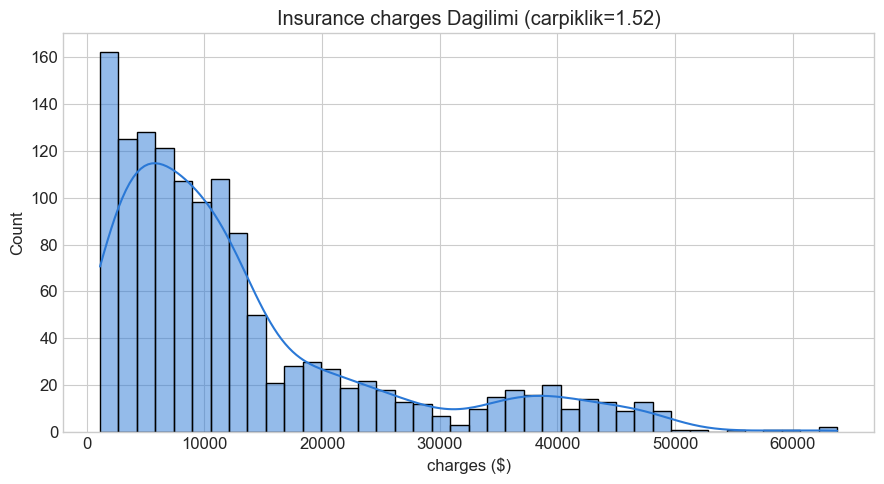

In [4]:
# OLS Regresyon Modeli
X_ols = pd.get_dummies(insurance[['age', 'bmi', 'children', 'sex', 'smoker', 'region']], drop_first=True) # drop_first=True ile dummy variable trap önlenir (One-Hot Encoding)
X_ols = X_ols.astype(float) # Float tipine dönüştürme, OLS modelinde gereklidir
y = insurance['charges'].astype(float) # Hedef değişkeni float tipine dönüştürme

X_ols_const = sm.add_constant(X_ols) # Sabit terim ekleme (intercept)
ols_model = sm.OLS(y, X_ols_const).fit() # OLS modelini fit etme

print(ols_model.summary().tables[1])
print(f"\nR-squared: {ols_model.rsquared:.4f}")
print(f"charges carpiklik (skewness): {y.skew():.2f}  (0'a yakinsa simetrik, >1 guclu sagda carpik)")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(y, bins=40, kde=True, color='#2a78d6', ax=ax)
ax.set_title(f'Insurance charges Dagilimi (carpiklik={y.skew():.2f})')
ax.set_xlabel('charges ($)')
plt.tight_layout()
plt.show()

### 🔗 Python 3 — Çoklu Bağlantı Kontrolü: VIF

**Ne yapıyoruz?**
Bölüm 2.2'deki VIF formülünü `statsmodels`'in hazır fonksiyonuyla hesaplıyoruz. Bu veri setinde değişken sayısı az olduğu için ciddi bir çoklu bağlantı beklemiyoruz — asıl amaç, Bölüm 4-6'daki Ridge/Lasso/Elastic Net'i **gerektiğinde** ne ölçtüğümüzü somut görmek. Yapay olarak `age` ile güçlü korelasyonlu bir `age_squared` türetilmiş özelliği ekleyip VIF'in nasıl patladığını da gösteriyoruz — gerçek dünyada polinom/etkileşim terimleri eklemek tam olarak bu sorunu yaratır.

In [5]:
vif_df = pd.DataFrame({'degisken': X_ols.columns})
vif_df['VIF'] = [variance_inflation_factor(X_ols.values, i) for i in range(X_ols.shape[1])]
print("=== Orijinal degiskenlerle VIF ===")
print(vif_df.sort_values('VIF', ascending=False).to_string(index=False))

# age_squared eklenince ne olur?
X_demo = X_ols.copy()
X_demo['age_squared'] = insurance['age'].astype(float) ** 2
vif_demo = pd.DataFrame({'degisken': X_demo.columns})
vif_demo['VIF'] = [variance_inflation_factor(X_demo.values, i) for i in range(X_demo.shape[1])]
print("\n=== age_squared eklenince VIF (coklu baglanti demosu) ===")
print(vif_demo.sort_values('VIF', ascending=False).to_string(index=False))
print("\nYORUM: age ve age_squared neredeyse birebir ayni bilgiyi tasidigi icin VIF'leri 10'un cok uzerine cikti -- Bolum 4-6'daki duzenlilestirme yontemleri boyle durumlar icindir.")

=== Orijinal degiskenlerle VIF ===
        degisken       VIF
             bmi 11.358443
             age  7.686965
region_southeast  2.265564
        sex_male  2.003185
region_southwest  1.960745
region_northwest  1.890281
        children  1.809930
      smoker_yes  1.261233

=== age_squared eklenince VIF (coklu baglanti demosu) ===
        degisken        VIF
             age 125.660164
     age_squared  54.315653
             bmi  22.341217
region_southeast   2.268475
        sex_male   2.025580
region_southwest   2.000461
region_northwest   1.963291
        children   1.946374
      smoker_yes   1.269645

YORUM: age ve age_squared neredeyse birebir ayni bilgiyi tasidigi icin VIF'leri 10'un cok uzerine cikti -- Bolum 4-6'daki duzenlilestirme yontemleri boyle durumlar icindir.


### 📈 Python 4 — Ridge Regression: Katsayı Yolu ve `RidgeCV`

**Ne yapıyoruz?**
`age_squared`'i de içeren genişletilmiş (kasıtlı çoklu bağlantılı) özellik setiyle, geniş bir `alpha` (Bölüm 3'teki $\lambda$) aralığında Ridge fit edip katsayıların nasıl küçüldüğünü (shrinkage path) çiziyoruz. Sonra `RidgeCV` ile çapraz doğrulamayla en iyi `alpha`'yı otomatik seçiyoruz. Sayısal kararlılık için tüm özellikleri önce standardize ediyoruz (Ridge/Lasso ölçeğe duyarlıdır — `data_preprocessing.ipynb` Bölüm 6.1).

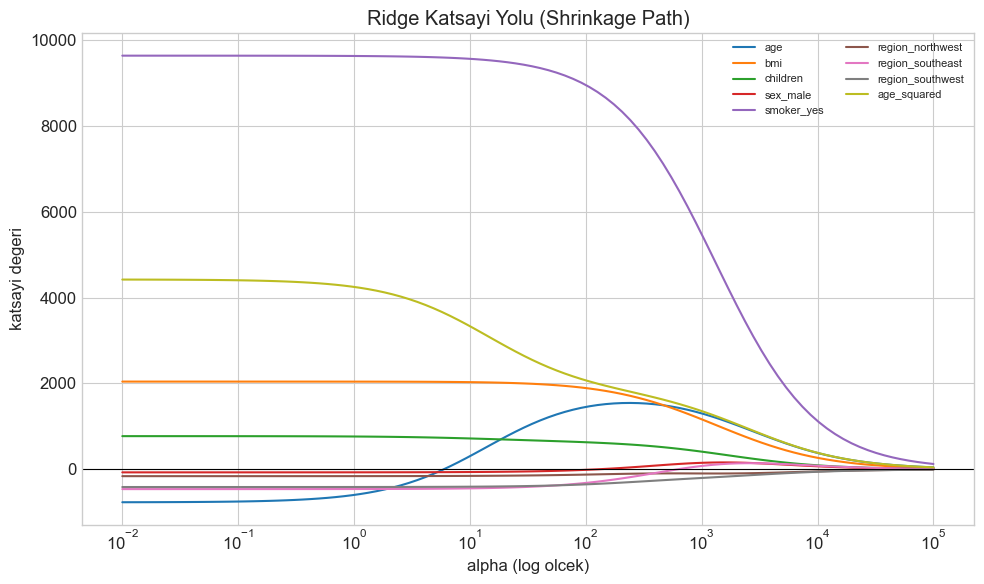

RidgeCV secilen alpha: 2.154
RidgeCV R^2 (train): 0.7537


In [6]:
X_reg = X_demo.copy()  # age, bmi, children, sex_male, smoker_yes, region_*, age_squared
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

alphas = np.logspace(-2, 5, 100)
ridge_coefs = []
for a in alphas:
    r = Ridge(alpha=a).fit(X_reg_scaled, y)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

fig, ax = plt.subplots(figsize=(10, 6))
for i, col in enumerate(X_reg.columns):
    ax.plot(alphas, ridge_coefs[:, i], label=col)
ax.set_xscale('log')
ax.set_xlabel('alpha (log olcek)')
ax.set_ylabel('katsayi degeri')
ax.set_title('Ridge Katsayi Yolu (Shrinkage Path)')
ax.legend(fontsize=8, ncol=2)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_reg_scaled, y)
print(f"RidgeCV secilen alpha: {ridge_cv.alpha_:.3f}")
print(f"RidgeCV R^2 (train): {ridge_cv.score(X_reg_scaled, y):.4f}")

### 🎯 Python 5 — Lasso Regression: Katsayı Yolu ve Sıfırlanan Özellikler

**Ne yapıyoruz?**
Aynı yolu Lasso ile çiziyoruz — bu sefer katsayıların gerçekten **sıfıra** ulaştığını göreceğiz (Bölüm 4'teki elmas-şekilli kısıt bölgesinin köşe etkisi). `LassoCV` ile en iyi `alpha`'yı seçip, o noktada hangi özelliklerin modelden tamamen atıldığını listeliyoruz.

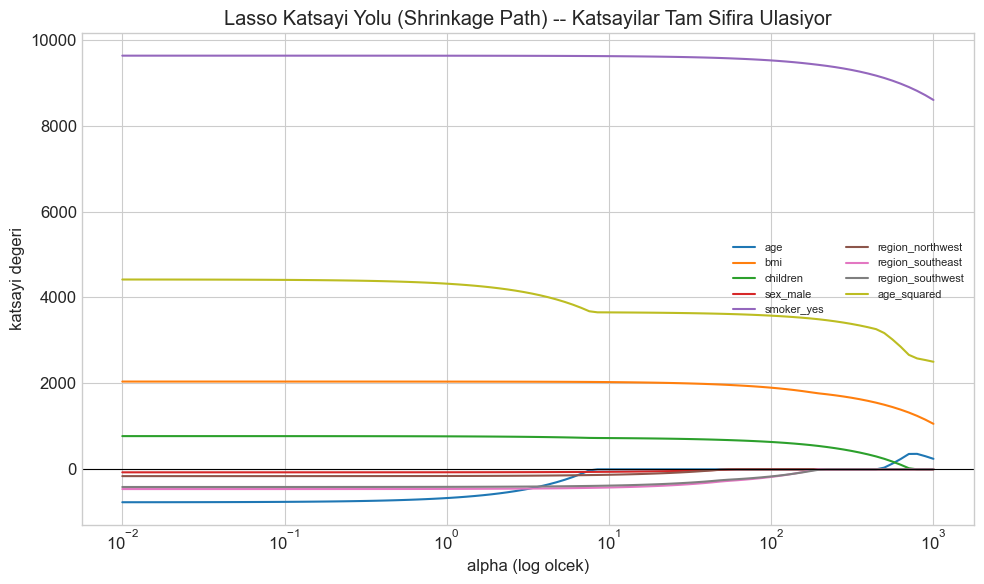

LassoCV secilen alpha: 54.623

Secilen (sifirlanmayan) ozellikler:
smoker_yes          9567.200261
age_squared         3616.076279
bmi                 1965.010604
children             681.029735
region_southeast    -267.742426
region_southwest    -240.598904
sex_male              -5.952446
dtype: float64

Sifirlanan (elenen) ozellikler:
['age', 'region_northwest']

LassoCV R^2 (train): 0.7533


In [7]:
lasso_alphas = np.logspace(-2, 3, 100)
lasso_coefs = []
for a in lasso_alphas:
    l = Lasso(alpha=a, max_iter=20000).fit(X_reg_scaled, y)
    lasso_coefs.append(l.coef_)
lasso_coefs = np.array(lasso_coefs)

fig, ax = plt.subplots(figsize=(10, 6))
for i, col in enumerate(X_reg.columns):
    ax.plot(lasso_alphas, lasso_coefs[:, i], label=col)
ax.set_xscale('log')
ax.set_xlabel('alpha (log olcek)')
ax.set_ylabel('katsayi degeri')
ax.set_title('Lasso Katsayi Yolu (Shrinkage Path) -- Katsayilar Tam Sifira Ulasiyor')
ax.legend(fontsize=8, ncol=2)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

lasso_cv = LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000).fit(X_reg_scaled, y)
print(f"LassoCV secilen alpha: {lasso_cv.alpha_:.3f}")
selected = pd.Series(lasso_cv.coef_, index=X_reg.columns)
print("\nSecilen (sifirlanmayan) ozellikler:")
print(selected[selected != 0].sort_values(key=abs, ascending=False))
print("\nSifirlanan (elenen) ozellikler:")
print(selected[selected == 0].index.tolist())
print(f"\nLassoCV R^2 (train): {lasso_cv.score(X_reg_scaled, y):.4f}")

### 🧬 Python 6 — Elastic Net: L1 Oranının Etkisi

**Ne yapıyoruz?**
`ElasticNetCV` ile hem `alpha` hem `l1_ratio` (Bölüm 5'teki $\alpha$) çapraz doğrulamayla taranıyor. Farklı `l1_ratio` değerlerinde kaç özelliğin sıfırlanmadan kaldığını karşılaştırarak Ridge (l1_ratio→0) ile Lasso (l1_ratio→1) arasındaki geçişi somut görüyoruz.

In [8]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
en_cv = ElasticNetCV(l1_ratio=l1_ratios, alphas=np.logspace(-2, 2, 50), cv=5, max_iter=20000)
en_cv.fit(X_reg_scaled, y)
print(f"ElasticNetCV secilen alpha: {en_cv.alpha_:.4f}, l1_ratio: {en_cv.l1_ratio_}")

rows = []
for l1r in l1_ratios:
    m = ElasticNet(alpha=en_cv.alpha_, l1_ratio=l1r, max_iter=20000).fit(X_reg_scaled, y)
    n_nonzero = int(np.sum(m.coef_ != 0))
    rows.append({'l1_ratio': l1r, 'sifirlanmayan_ozellik_sayisi': n_nonzero, 'R2_train': m.score(X_reg_scaled, y)})
pd.DataFrame(rows)

# l1_ratio arttıkça lasso'ya yaklaşır baktığımızda tabloda sıfırlanan özellik sayısı artmıyor çünkü veri setinde zaten lasso ile sıfırlanan özellik sayısı az. Bu nedenle l1_ratio arttıkça R^2 değeri de artıyor.

ElasticNetCV secilen alpha: 0.2024, l1_ratio: 0.99


,l1_ratio,sifirlanmayan_ozellik_sayisi,R2_train
0,0.10,9,0.736116
1,0.30,9,0.741998
2,0.50,9,0.746936
3,0.70,9,0.750676
4,0.90,9,0.753009
5,0.99,9,0.753685


### 📋 Python 7 — Model Karşılaştırma: OLS vs Ridge vs Lasso vs Elastic Net

**Ne yapıyoruz?**
Dört yöntemi aynı train/test bölünmesinde (%80/%20) karşılaştırıyoruz — RMSE, $R^2$ ve kaç katsayının sıfır olmadığı (`n_nonzero`, model karmaşıklığının bir göstergesi).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_reg_scaled, y, test_size=0.2, random_state=42)

models = {
    'OLS': LinearRegression(),
    'Ridge (CV)': Ridge(alpha=ridge_cv.alpha_),
    'Lasso (CV)': Lasso(alpha=lasso_cv.alpha_, max_iter=20000),
    'Elastic Net (CV)': ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_, max_iter=20000),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results.append({
        'model': name, 
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)), # Root Mean Squared Error
        'R2': r2_score(y_test, pred), # R-squared
        'n_nonzero_coef': int(np.sum(np.abs(m.coef_) > 1e-8)), # Sıfır olmayan katsayı sayısı (1e-8 eşiği ile) 
    })
comparison_df = pd.DataFrame(results).round(3)
comparison_df

,model,RMSE,R2,n_nonzero_coef
0,OLS,5758.195,0.786,9
1,Ridge (CV),5760.588,0.786,9
2,Lasso (CV),5783.182,0.785,6
3,Elastic Net (CV),5760.725,0.786,9


### ⚠️ Python 8 — Dayanıklı Regresyon Motivasyonu: Auto MPG'de Sensör Hatası Senaryosu

**Ne yapıyoruz?**
Auto MPG verisi doğal hâliyle ağır aykırı değerler içermiyor — bu yüzden **gerçekçi bir senaryo simüle ediyoruz** (scikit-learn'ün kendi robust regression dokümantasyonunda da izlenen standart yöntem): en yüksek beygir gücüne (horsepower) sahip 12 aracın `mpg` değerini yapay olarak yukarı kaydırıyoruz — otomotiv/üretim endüstrisinde telemetri sensörlerinin ara sıra hatalı okuma yapması (kalibrasyon kayması, veri iletim hatası) gerçek bir problemdir, ve bu tam olarak OLS'i en çok kıracak türden bir **kaldıraç noktası (leverage point)** senaryosudur: hem $x$ ekseninde uçta (yüksek beygir gücü) hem de $y$'de tutarsız.

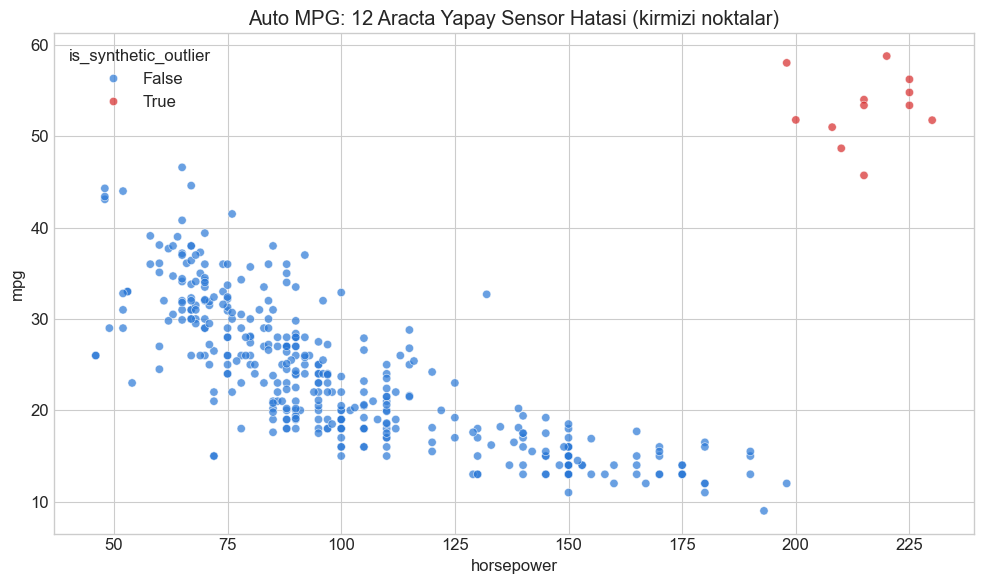

Yapay olarak bozulan gozlem sayisi: 12 / 392


In [10]:
rng = np.random.RandomState(7)
mpg_corrupted = mpg.copy()
high_hp_idx = mpg_corrupted.sort_values('horsepower', ascending=False).index[:12]
mpg_corrupted.loc[high_hp_idx, 'mpg'] = mpg_corrupted.loc[high_hp_idx, 'mpg'] + rng.uniform(35, 45, size=len(high_hp_idx))
mpg_corrupted['is_synthetic_outlier'] = mpg_corrupted.index.isin(high_hp_idx)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=mpg_corrupted, x='horsepower', y='mpg', hue='is_synthetic_outlier',
                 palette={False: '#2a78d6', True: '#d62a2a'}, alpha=0.7, ax=ax)
ax.set_title('Auto MPG: 12 Aracta Yapay Sensor Hatasi (kirmizi noktalar)')
plt.tight_layout()
plt.show()

print(f"Yapay olarak bozulan gozlem sayisi: {mpg_corrupted['is_synthetic_outlier'].sum()} / {len(mpg_corrupted)}")

### 🛡️ Python 9-11 — Huber, RANSAC, Theil-Sen: Bozuk Veride Dört Yöntemin Karşılaştırması

**Ne yapıyoruz?**
Bozulmuş veri üzerinde OLS, Huber, RANSAC ve Theil-Sen'i tek bir öngörücüyle (`horsepower`) fit ediyoruz, katsayıları temiz (bozulmamış) veriden elde edilen OLS referansıyla karşılaştırıyoruz. Amaç: hangi yöntemlerin "gerçek" eğime (temiz veri eğimine) yakın kaldığını görmek.

In [11]:
# Kirli veri ile OLS, Huber, RANSAC ve Theil-Sen regresyon modellerini fit edelim ve katsayıları karşılaştıralım.
X_mpg = mpg_corrupted[['horsepower']].values.astype(float)
y_mpg = mpg_corrupted['mpg'].values.astype(float)

# Temiz veri ile referans OLS modeli
clean_ref = LinearRegression().fit(mpg[['horsepower']].values.astype(float), mpg['mpg'].values.astype(float))

robust_models = {
    'OLS (bozuk veri)': LinearRegression().fit(X_mpg, y_mpg),
    'Huber': HuberRegressor(max_iter=500).fit(X_mpg, y_mpg),
    'RANSAC': RANSACRegressor(random_state=42).fit(X_mpg, y_mpg),
    'Theil-Sen': TheilSenRegressor(random_state=42).fit(X_mpg, y_mpg),
}

rows = []
for name, m in robust_models.items():
    if name == 'RANSAC':
        slope, intercept = m.estimator_.coef_[0], m.estimator_.intercept_
    else:
        slope, intercept = m.coef_[0], m.intercept_
    rows.append({'model': name, 'egim (slope)': slope, 'kesim (intercept)': intercept})
rows.append({'model': 'OLS (TEMIZ veri, referans)', 'egim (slope)': clean_ref.coef_[0], 'kesim (intercept)': clean_ref.intercept_})
robust_summary = pd.DataFrame(rows).round(4)
robust_summary

# Temiz veride eğim (slope) ve kesim (intercept) değerleri ile bozuk verideki OLS modelinin değerleri oldukça farklı. Huber, RANSAC ve Theil-Sen gibi robust modeller ise bozuk veriye karşı daha dayanıklı ve temiz veri ile daha yakın sonuçlar veriyor.

,model,egim (slope),kesim (intercept)
0,OLS (bozuk veri),-0.0653,31.4981
1,Huber,-0.1565,39.4331
2,RANSAC,-0.1816,42.9532
3,Theil-Sen,-0.1762,41.6000
4,"OLS (TEMIZ veri, referans)",-0.1578,39.9359


### 📉 Python 12 — Dört Yöntemin Fit Çizgilerini Görselleştirme

**Ne yapıyoruz?**
Aynı grafik üzerinde 4 modelin fit çizgisini + temiz-veri referansını çiziyoruz. OLS çizgisinin, yüksek beygir gücündeki bozuk noktalara doğru nasıl "çekildiğini" (daha yatay bir eğim = gerçek negatif ilişkiyi olduğundan zayıf gösteriyor), diğer üç yöntemin ise referansa ne kadar yakın kaldığını görsel olarak karşılaştırıyoruz.

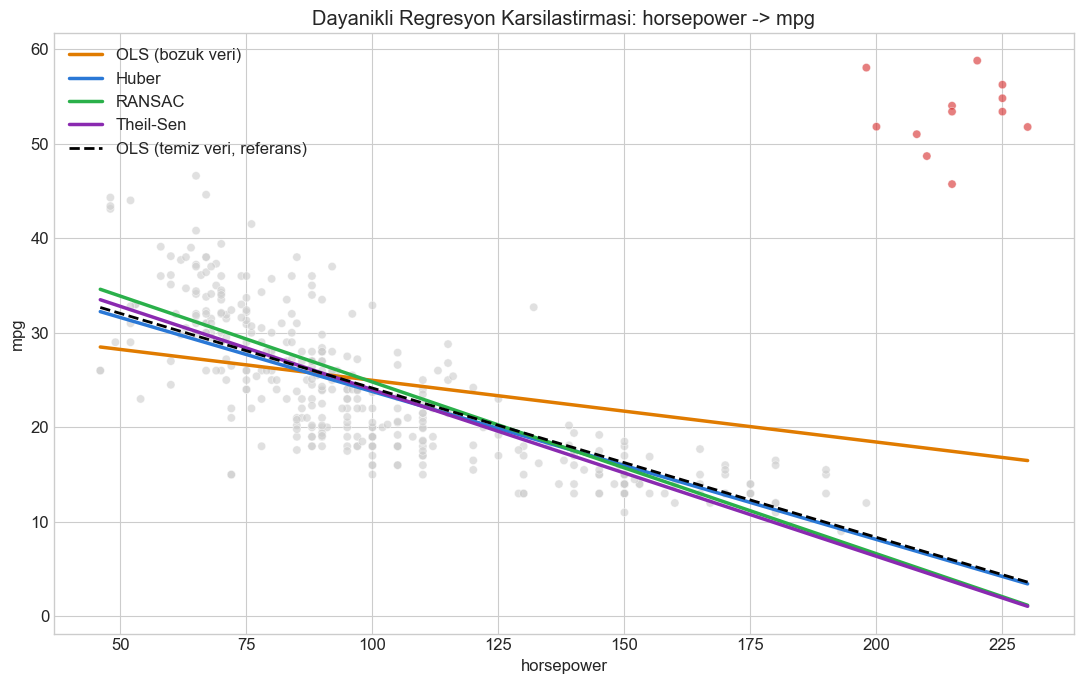

YORUM: OLS'un egimi bozuk veride -0.065'e kadar duzlesti, temiz referanstan (-0.158) belirgin bicimde saptı;
Huber, RANSAC ve Theil-Sen ise referansa cok daha yakin kaldi -- Huber daha yakın Theil-Sen ile RANSAC birbiriyle çok yakın. RANSAC, bozuk noktalari 'inlier' kumesinin disinda birakarak neredeyse temiz veri sonucunu yeniden uretti.


In [12]:
x_range = np.linspace(mpg_corrupted['horsepower'].min(), mpg_corrupted['horsepower'].max(), 100).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=mpg_corrupted, x='horsepower', y='mpg', hue='is_synthetic_outlier',
                 palette={False: '#cccccc', True: '#d62a2a'}, alpha=0.6, ax=ax, legend=False)

colors = {'OLS (bozuk veri)': '#e07b00', 'Huber': '#2a78d6', 'RANSAC': '#2ab04a', 'Theil-Sen': '#8a2ab0'}
for name, m in robust_models.items():
    pred = m.predict(x_range)
    ax.plot(x_range, pred, label=name, color=colors[name], linewidth=2.5)
ax.plot(x_range, clean_ref.predict(x_range), label='OLS (temiz veri, referans)', color='black', linestyle='--', linewidth=2)

ax.set_title('Dayanikli Regresyon Karsilastirmasi: horsepower -> mpg')
ax.set_xlabel('horsepower')
ax.set_ylabel('mpg')
ax.legend()
plt.tight_layout()
plt.show()

ols_slope_corrupted = robust_models['OLS (bozuk veri)'].coef_[0]
clean_slope = clean_ref.coef_[0]
print(f"YORUM: OLS'un egimi bozuk veride {ols_slope_corrupted:.3f}'e kadar duzlesti, temiz referanstan ({clean_slope:.3f}) belirgin bicimde saptı;")
print("Huber, RANSAC ve Theil-Sen ise referansa cok daha yakin kaldi -- Huber daha yakın Theil-Sen ile RANSAC birbiriyle çok yakın. RANSAC, bozuk noktalari 'inlier' kumesinin disinda birakarak neredeyse temiz veri sonucunu yeniden uretti.")

### 📐 Python 13 — Quantile Regression: Insurance Charges'te Persentil Tahmini

**Ne yapıyoruz?**
Insurance verisinde `charges`'i, tek bir ortalama tahmini yerine üç farklı persentil ($\tau=0.1, 0.5, 0.9$) için ayrı ayrı modelliyoruz. `age`'e göre bu üç tahmin çizgisini çizip aralarındaki **açılan makasın** ne anlama geldiğini yorumluyoruz — bu, Bölüm 6.4'teki "sigorta rezervi/güvenlik stoğu" endüstri örneğinin doğrudan uygulaması.

tau=0.1: egitim verisinde gozlemlerin 10.1%'i tahminin altinda kaliyor (hedef: 10%)
tau=0.5: egitim verisinde gozlemlerin 50.0%'i tahminin altinda kaliyor (hedef: 50%)
tau=0.9: egitim verisinde gozlemlerin 90.1%'i tahminin altinda kaliyor (hedef: 90%)


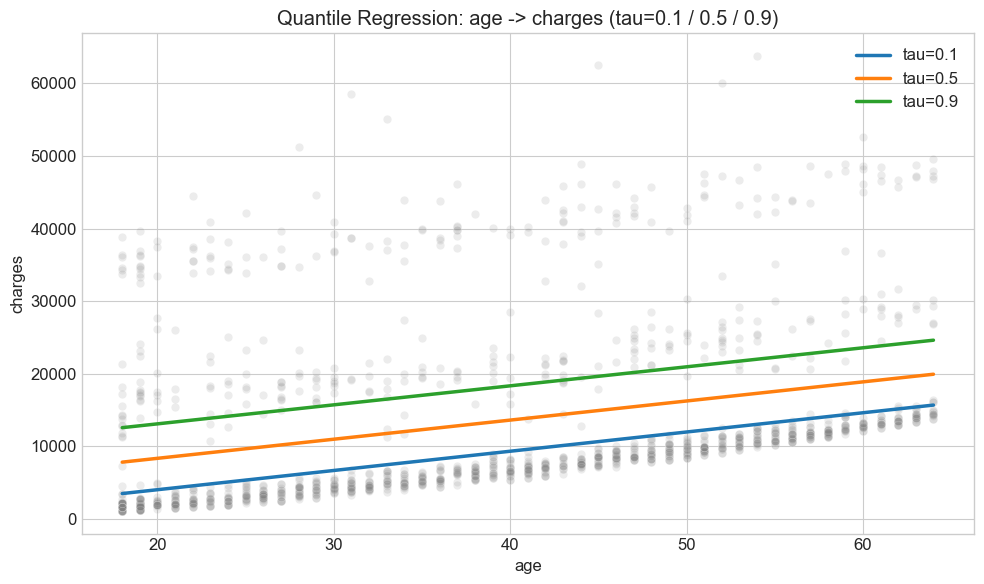


YORUM: Farklı tau değerleriyle birlikte Tweedie bize sigorta primlerinin dağılımını daha iyi anlamamızı sağlar. Tau=0.1 ile düşük primler, tau=0.5 ile medyan primler ve tau=0.9 ile yüksek primler için tahminler elde edebiliriz. Bu, risk yönetimi ve fiyatlandırma stratejileri için önemli bilgiler sunar.


In [13]:
X_q = pd.get_dummies(insurance[['age', 'bmi', 'children', 'sex', 'smoker', 'region']], drop_first=True).astype(float) # One-Hot Encoding ve float tipine dönüştürme
X_q_scaled = StandardScaler().fit_transform(X_q)

quantiles = [0.1, 0.5, 0.9]
quantile_models = {}
for tau in quantiles:
    qr = QuantileRegressor(quantile=tau, alpha=0.0, solver='highs')
    qr.fit(X_q_scaled, y)
    quantile_models[tau] = qr
    pred_in_sample = qr.predict(X_q_scaled)
    coverage = np.mean(y <= pred_in_sample)
    print(f"tau={tau}: egitim verisinde gozlemlerin {coverage:.1%}'i tahminin altinda kaliyor (hedef: {tau:.0%})")

# age'e gore tahmin egrileri (diger degiskenler ortalamada sabit tutularak)
age_grid = pd.DataFrame({
    'age': np.linspace(insurance['age'].min(), insurance['age'].max(), 50)
})
base_row = X_q.mean()
grid_X = pd.DataFrame([base_row.values] * len(age_grid), columns=X_q.columns)
grid_X['age'] = age_grid['age'].values
grid_X_scaled = StandardScaler().fit(X_q).transform(grid_X)

fig, ax = plt.subplots(figsize=(10, 6))
for tau, qr in quantile_models.items():
    ax.plot(age_grid['age'], qr.predict(grid_X_scaled), label=f'tau={tau}', linewidth=2.5)
sns.scatterplot(data=insurance, x='age', y='charges', alpha=0.15, color='gray', ax=ax)
ax.set_title('Quantile Regression: age -> charges (tau=0.1 / 0.5 / 0.9)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Farklı tau değerleriyle birlikte Tweedie bize sigorta primlerinin dağılımını daha iyi anlamamızı sağlar. Tau=0.1 ile düşük primler, tau=0.5 ile medyan primler ve tau=0.9 ile yüksek primler için tahminler elde edebiliriz. Bu, risk yönetimi ve fiyatlandırma stratejileri için önemli bilgiler sunar.")

### 🧮 Python 14-16 — Poisson GLM: Ships Damage Data

**Ne yapıyoruz?**
Bölüm 7.1'deki klasik McCullagh & Nelder örneğini yeniden üretiyoruz: gemi **tipi**, **inşa yılı** ve **işletim dönemi**ne göre hasar **insiyanı sayısını**, `log(service)` (toplam hizmet ayı) offset olarak ekleyerek Poisson GLM ile modelliyoruz. Sonra aşırı dağılım (overdispersion) kontrolü yapıp Negative Binomial ile karşılaştırıyoruz.

In [14]:
ships_fit = ships.copy()
ships_fit['log_service'] = np.log(ships_fit['service'])

poisson_model = smf.glm(
    'incidents ~ type + year + period', data=ships_fit,
    family=sm.families.Poisson(), offset=ships_fit['log_service']
).fit()
print(poisson_model.summary())

irr = np.exp(poisson_model.params)
print("\n=== Insidan Orani Oranlari (Incident Rate Ratios, exp(katsayi)) ===")
print(irr.round(3))
print("\nYORUM: type[T.B] icin IRR ~", round(irr['type[T.B]'], 3), "-- B tipi gemiler, A tipine (referans - Type.A yani referans olarak 1 dediğimiz değerden) gore ayni hizmet suresinde")
print("yaklasik", f"{(1 - irr['type[T.B]'])*100:.0f}%", "daha az hasar insidanina sahip (diger degiskenler sabitken).")

print("\nYORUM: Öbür tiplerin A tipi yani referans gemiye göre kaza oranlarının artış ve azalışları gösteriyor. Ayrıca öbür yıllara göre de referans olan 60'lı yıla göre kaza oranlarının değiştiğini göstermektir.")

                 Generalized Linear Model Regression Results                  
Dep. Variable:              incidents   No. Observations:                   34
Model:                            GLM   Df Residuals:                       25
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -68.281
Date:                Fri, 21 Aug 2026   Deviance:                       38.695
Time:                        14:28:55   Pearson chi2:                     42.3
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9578
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -6.4059      0.217    -29.460   

In [15]:
deviance_over_df = poisson_model.deviance / poisson_model.df_resid # Deviance (Sapma) / Artıkların serbestlik derecesini
pearson_chi2_over_df = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"Deviance / df: {deviance_over_df:.3f}")
print(f"Pearson chi2 / df: {pearson_chi2_over_df:.3f}")
print("(1.0'a yakinsa esdagilim (equidispersion) makul; belirgin sekilde >1 ise asiri dagilim (overdispersion) isareti)")

nb_model = smf.glm(
    'incidents ~ type + year + period', data=ships_fit,
    family=sm.families.NegativeBinomial(alpha=1.0), offset=ships_fit['log_service']
).fit()  # alpha=1.0: basitlik icin sabit dispersiyon parametresi (tam NB2 profil-olabilirlik disi kapsam)

print(f"\nPoisson AIC: {poisson_model.aic:.2f}, AIC ne kadar kucukse model o kadar iyi; AIC, modelin uyumunu ve kompleksligini birlikte degerlendirir.")
print(f"Negative Binomial AIC: {nb_model.aic:.2f}")
print("\nYORUM: Deviance/df 1'in oldukca uzerinde oldugu icin hafif asiri dagilim var;")
print("Negative Binomial, ekstra bir dispersiyon parametresiyle bunu modelleyerek standart hatalari daha guvenilir hale getirir.")

Deviance / df: 1.548
Pearson chi2 / df: 1.691
(1.0'a yakinsa esdagilim (equidispersion) makul; belirgin sekilde >1 ise asiri dagilim (overdispersion) isareti)

Poisson AIC: 154.56, AIC ne kadar kucukse model o kadar iyi; AIC, modelin uyumunu ve kompleksligini birlikte degerlendirir.
Negative Binomial AIC: 185.45

YORUM: Deviance/df 1'in oldukca uzerinde oldugu icin hafif asiri dagilim var;
Negative Binomial, ekstra bir dispersiyon parametresiyle bunu modelleyerek standart hatalari daha guvenilir hale getirir.


### 💰 Python 17 — Gamma GLM: Insurance Charges'in Büyüklüğü

**Ne yapıyoruz?**
`charges`'i (Python 2'de çarpıklığını gördüğümüz) log-link Gamma GLM ile modelliyoruz. Katsayıları $\exp(\beta)$ ile çarpımsal etki olarak yorumluyoruz — örneğin `smoker_yes` katsayısı, sigara içmenin maliyeti **yüzde kaç** artırdığını doğrudan verir.

In [16]:
X_glm = pd.get_dummies(insurance[['age', 'bmi', 'children', 'sex', 'smoker', 'region']], drop_first=True).astype(float)
X_glm_const = sm.add_constant(X_glm)

gamma_model = sm.GLM(y, X_glm_const, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
print(gamma_model.summary().tables[1])

gamma_effects = np.exp(gamma_model.params.drop('const')) - 1
print("\n=== Carpimsal Etkiler ((exp(katsayi)-1) -> yuzde degisim, const haric) ===")
print((gamma_effects * 100).round(1).astype(str) + '%')
print(f"\nYORUM: smoker_yes -> charges'i yaklasik {gamma_effects['smoker_yes']*100:.0f}% artiriyor (diger degiskenler sabitken) -- OLS'un dogrudan $ cinsinden katsayisindan cok daha yorumlanabilir bir olcek.")

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                7.3863      0.111     66.334      0.000       7.168       7.605
age                  0.0286      0.001     21.351      0.000       0.026       0.031
bmi                  0.0141      0.003      4.381      0.000       0.008       0.020
children             0.0842      0.016      5.419      0.000       0.054       0.115
sex_male            -0.0571      0.038     -1.521      0.128      -0.131       0.016
smoker_yes           1.5003      0.047     32.215      0.000       1.409       1.592
region_northwest    -0.0579      0.054     -1.078      0.281      -0.163       0.047
region_southeast    -0.1416      0.054     -2.625      0.009      -0.247      -0.036
region_southwest    -0.1455      0.054     -2.700      0.007      -0.251      -0.040

=== Carpimsal Etkiler ((exp(katsayi)-1) -> yuzde degisim, const 

### 🌪️ Python 18 — Tweedie GLM: Güç Parametresi Taraması

**Ne yapıyoruz?**
Bölüm 7.3'teki $p$ (güç/`var_power`) parametresini $1.1$'den $1.9$'a tarayarak her değer için deviance ve AIC hesaplıyoruz. En düşük AIC'yi veren $p$, bu veri için "bileşik Poisson-Gamma" davranışının en iyi hangi noktada olduğunu gösterir — sigorta pratiğinde saf prim modellemesinde genelde $p \in (1, 2)$ aralığında bir değer tercih edilir.

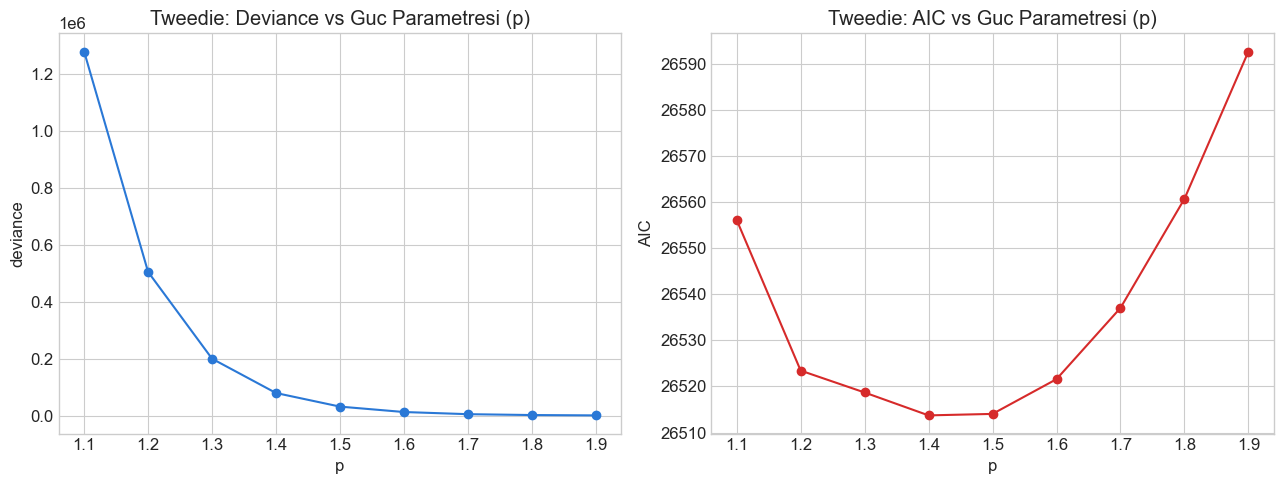

 var_power (p)  deviance     AIC
           1.1 1277960.3 26556.1
           1.2  504406.4 26523.4
           1.3  199720.7 26518.7
           1.4   79343.5 26513.7
           1.5   31631.3 26514.0
           1.6   12656.6 26521.6
           1.7    5083.7 26537.0
           1.8    2050.2 26560.7
           1.9     830.3 26592.7

YORUM: En dusuk AIC'yi p=1.4 civarinda goruyoruz -- bu, p=1 (saf Poisson) ile p=2 (saf Gamma) arasinda,
bilesik Poisson-Gamma davranisinin bu veri icin en uygun oldugu bolgeyi isaret ediyor (aktueryal pratikte tipik aralik).


In [17]:
power_grid = np.arange(1.1, 1.95, 0.1)
tweedie_results = []
for p in power_grid:
    tw = sm.GLM(y, X_glm_const, family=sm.families.Tweedie(var_power=p, link=sm.families.links.Log())).fit()
    tweedie_results.append({'var_power (p)': round(p, 2), 'deviance': tw.deviance, 'AIC': tw.aic})
tweedie_df = pd.DataFrame(tweedie_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(tweedie_df['var_power (p)'], tweedie_df['deviance'], marker='o', color='#2a78d6')
axes[0].set_title('Tweedie: Deviance vs Guc Parametresi (p)')
axes[0].set_xlabel('p'); axes[0].set_ylabel('deviance')
axes[1].plot(tweedie_df['var_power (p)'], tweedie_df['AIC'], marker='o', color='#d62a2a')
axes[1].set_title('Tweedie: AIC vs Guc Parametresi (p)')
axes[1].set_xlabel('p'); axes[1].set_ylabel('AIC')
plt.tight_layout()
plt.show()

best_p = tweedie_df.loc[tweedie_df['AIC'].idxmin(), 'var_power (p)']
print(tweedie_df.round(1).to_string(index=False))
print(f"\nYORUM: En dusuk AIC'yi p={best_p} civarinda goruyoruz -- bu, p=1 (saf Poisson) ile p=2 (saf Gamma) arasinda,")
print("bilesik Poisson-Gamma davranisinin bu veri icin en uygun oldugu bolgeyi isaret ediyor (aktueryal pratikte tipik aralik).")

### 🏁 Python 19 — Sentez: Tüm Modellerin Karşılaştırması

**Ne yapıyoruz?**
`charges` tahmini için OLS/Ridge/Lasso/Elastic Net/Gamma GLM/Tweedie GLM'i (aynı train/test bölünmesinde) RMSE ve $R^2$ üzerinden tek bir tabloda topluyoruz — bu notebook'un tüm ailesinin uçtan uca bir özeti.

In [18]:
X_syn = X_glm.values.astype(float)
X_syn_scaled = StandardScaler().fit_transform(X_syn)
X_syn_const = sm.add_constant(pd.DataFrame(X_syn, columns=X_glm.columns))

# ayni random_state -> ayni satirlar train/test'e ayrilir, boylece scaled ve const versiyonlar hizali kalir
Xtr, Xte, ytr, yte = train_test_split(X_syn_scaled, y, test_size=0.2, random_state=42)
Xtr_c, Xte_c, _, _ = train_test_split(X_syn_const, y, test_size=0.2, random_state=42)

synth_rows = []
for name, m in [('OLS', LinearRegression()), ('Ridge (CV)', Ridge(alpha=ridge_cv.alpha_)),
                 ('Lasso (CV)', Lasso(alpha=lasso_cv.alpha_, max_iter=20000)),
                 ('Elastic Net (CV)', ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_, max_iter=20000))]:
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    synth_rows.append({'model': name, 'RMSE': np.sqrt(mean_squared_error(yte, pred)), 'R2': r2_score(yte, pred)})

gamma_tr = sm.GLM(ytr, Xtr_c, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
gamma_pred = gamma_tr.predict(Xte_c)
synth_rows.append({'model': 'Gamma GLM', 'RMSE': np.sqrt(mean_squared_error(yte, gamma_pred)), 'R2': r2_score(yte, gamma_pred)})

tw_tr = sm.GLM(ytr, Xtr_c, family=sm.families.Tweedie(var_power=float(best_p), link=sm.families.links.Log())).fit()
tw_pred = tw_tr.predict(Xte_c)
synth_rows.append({'model': f'Tweedie GLM (p={best_p})', 'RMSE': np.sqrt(mean_squared_error(yte, tw_pred)), 'R2': r2_score(yte, tw_pred)})

final_comparison = pd.DataFrame(synth_rows).round(3).sort_values('RMSE')
print(final_comparison.to_string(index=False))
print("\nYORUM: OLS/Ridge/Lasso/Elastic Net, dogrudan kareler toplamini (RMSE ile ayni olcek) minimize ettikleri icin bu test setinde")
print("en dusuk RMSE'yi veriyor -- ama bu, Gamma/Tweedie GLM'in 'daha kotu' oldugu anlamina gelmez. GLM'ler farkli bir hedefi optimize eder")
print("(olabilirlik/likelihood), karsiliginda tahminlerin HER ZAMAN pozitif kalmasini garanti eder ve katsayilari carpimsal/yuzdesel olarak")
print("yorumlanabilir kilar (Python 17) -- sigorta fiyatlandirmasi gibi negatif tahminin kabul edilemez oldugu senaryolarda bu garanti,")
print("bir kac yuz dolarlik RMSE farkindan cok daha degerlidir.")

              model     RMSE    R2
                OLS 5796.285 0.784
         Ridge (CV) 5797.799 0.783
   Elastic Net (CV) 5797.881 0.783
         Lasso (CV) 5816.839 0.782
Tweedie GLM (p=1.4) 6004.980 0.768
          Gamma GLM 7306.532 0.656

YORUM: OLS/Ridge/Lasso/Elastic Net, dogrudan kareler toplamini (RMSE ile ayni olcek) minimize ettikleri icin bu test setinde
en dusuk RMSE'yi veriyor -- ama bu, Gamma/Tweedie GLM'in 'daha kotu' oldugu anlamina gelmez. GLM'ler farkli bir hedefi optimize eder
(olabilirlik/likelihood), karsiliginda tahminlerin HER ZAMAN pozitif kalmasini garanti eder ve katsayilari carpimsal/yuzdesel olarak
yorumlanabilir kilar (Python 17) -- sigorta fiyatlandirmasi gibi negatif tahminin kabul edilemez oldugu senaryolarda bu garanti,
bir kac yuz dolarlik RMSE farkindan cok daha degerlidir.


---
# 📊 R Uygulaması

Python bölümündeki akışın büyük kısmını R'da tekrarlıyoruz: düzenlileştirme için `glmnet`, dayanıklı regresyon için `MASS::rlm` (Huber) ve `mblm` (Theil-Sen), quantile regression için `quantreg`, GLM'ler için taban `glm()` (Tweedie için `statmod` paketinin `tweedie()` ailesiyle). RANSAC'ın R'da yaygın/standart bir karşılığı yoktur (Python/scikit-learn ekosisteminin, özellikle bilgisayarlı görüden gelen bir yöntemidir) — o adımı Python'da gördüğümüz sonuçlara referans vererek atlıyoruz.

In [19]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [20]:
%%R -i insurance -i ships_fit -i mpg_corrupted
# insurance, ships_fit (service>0 filtresi + log_service uygulanmis), mpg_corrupted (Python 8'deki sentetik aykiri degerli veri)
insurance$smoker <- as.factor(insurance$smoker)
insurance$sex <- as.factor(insurance$sex)
insurance$region <- as.factor(insurance$region)

ships_fit$type <- as.factor(ships_fit$type)
ships_fit$year <- as.factor(ships_fit$year)
ships_fit$period <- as.factor(ships_fit$period)

cat("insurance:", nrow(insurance), "satir |  ships_fit:", nrow(ships_fit), "satir  |  mpg_corrupted:", nrow(mpg_corrupted), "satir\n")

insurance: 1338 satir |  ships_fit: 34 satir  |  mpg_corrupted: 392 satir


/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "year". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/opt/anaconda3/lib/python3.13/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "period". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '


## 🅰️ R — Düzenlileştirme: `glmnet` ile Ridge / Lasso / Elastic Net

Ridge  en iyi lambda: 953.006 
Lasso  en iyi lambda: 68.81475 
ElasticNet en iyi lambda (alpha=0.5): 114.2624 

Lasso katsayilari (lambda.min'de):
9 x 1 sparse Matrix of class "dgCMatrix"
                 lambda.min
(Intercept)     -11566.9505
age                252.9685
bmi                322.5230
children           418.4944
sexmale              .     
smokeryes        23659.0533
regionnorthwest      .     
regionsoutheast   -547.1304
regionsouthwest   -513.6591


Loading required package: Matrix
Loaded glmnet 5.0


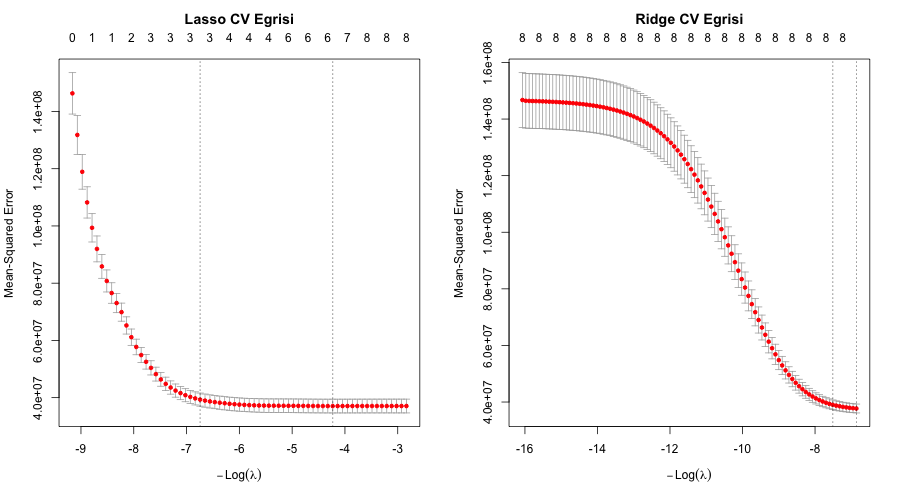

In [21]:
%%R -w 900 -h 500
# install.packages("glmnet") # ilk calistirmada gerekli olabilir
library(glmnet)

X_r <- model.matrix(charges ~ age + bmi + children + sex + smoker + region, data = insurance)[, -1]
y_r <- insurance$charges

# alpha = 0 -> Ridge, alpha = 1 -> Lasso, 0 < alpha < 1 -> Elastic Net
ridge_fit <- cv.glmnet(X_r, y_r, alpha = 0)
lasso_fit <- cv.glmnet(X_r, y_r, alpha = 1)
enet_fit  <- cv.glmnet(X_r, y_r, alpha = 0.5)

cat("Ridge  en iyi lambda:", ridge_fit$lambda.min, "\n")
cat("Lasso  en iyi lambda:", lasso_fit$lambda.min, "\n")
cat("ElasticNet en iyi lambda (alpha=0.5):", enet_fit$lambda.min, "\n\n")

cat("Lasso katsayilari (lambda.min'de):\n")
print(coef(lasso_fit, s = "lambda.min"))

par(mfrow = c(1, 2))
plot(lasso_fit); title("Lasso CV Egrisi", line = 2.5)
plot(ridge_fit); title("Ridge CV Egrisi", line = 2.5)

## 🅱️ R — Dayanıklı Regresyon: `MASS::rlm` (Huber) ve `mblm` (Theil-Sen)

OLS (bozuk veri)      egim: -0.06526794 
Huber (rlm)           egim: -0.1536749 
Theil-Sen (mblm)      egim: -0.1853662 


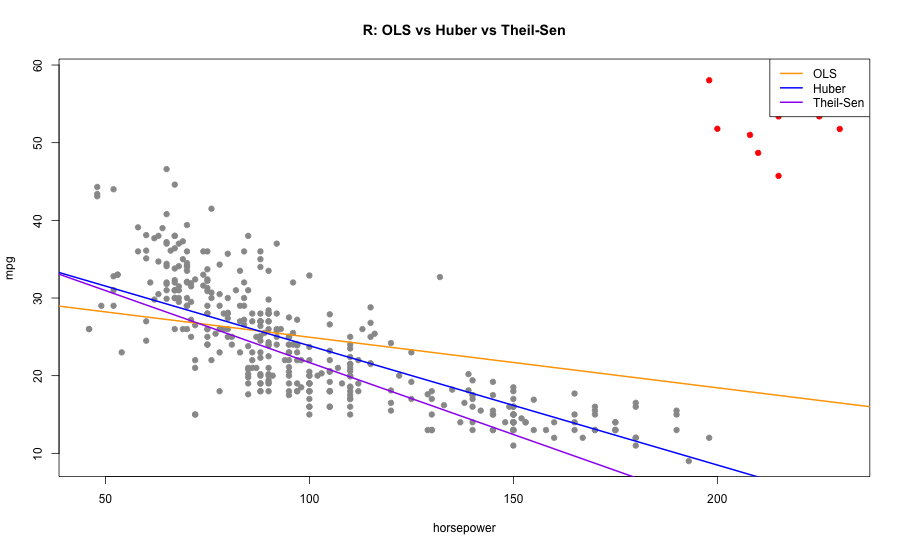

In [22]:
%%R -w 900 -h 550
# install.packages(c("MASS", "mblm")) # ilk calistirmada gerekli olabilir
library(MASS)
library(mblm)

ols_r   <- lm(mpg ~ horsepower, data = mpg_corrupted)
huber_r <- rlm(mpg ~ horsepower, data = mpg_corrupted, method = "M")  # M-estimation = Huber
ts_r    <- mblm(mpg ~ horsepower, dataframe = mpg_corrupted)          # Theil-Sen (mblm = "Median-Based Linear Models")

cat("OLS (bozuk veri)      egim:", coef(ols_r)[2], "\n")
cat("Huber (rlm)           egim:", coef(huber_r)[2], "\n")
cat("Theil-Sen (mblm)      egim:", coef(ts_r)[2], "\n")

plot(mpg_corrupted$horsepower, mpg_corrupted$mpg, col = ifelse(mpg_corrupted$is_synthetic_outlier, "red", "gray60"),
     pch = 19, xlab = "horsepower", ylab = "mpg", main = "R: OLS vs Huber vs Theil-Sen")
abline(ols_r, col = "orange", lwd = 2)
abline(huber_r, col = "blue", lwd = 2)
abline(ts_r, col = "purple", lwd = 2)
legend("topright", legend = c("OLS", "Huber", "Theil-Sen"), col = c("orange", "blue", "purple"), lwd = 2)

## 🎯 R — Quantile Regression: `quantreg::rq`

In [23]:
%%R
# install.packages("quantreg") # ilk calistirmada gerekli olabilir
library(quantreg)

rq_10 <- rq(charges ~ age + bmi + children + sex + smoker + region, data = insurance, tau = 0.1)
rq_50 <- rq(charges ~ age + bmi + children + sex + smoker + region, data = insurance, tau = 0.5)
rq_90 <- rq(charges ~ age + bmi + children + sex + smoker + region, data = insurance, tau = 0.9)

cat("tau=0.1 icin 'age' katsayisi:", coef(rq_10)["age"], "\n")
cat("tau=0.5 icin 'age' katsayisi:", coef(rq_50)["age"], "\n")
cat("tau=0.9 icin 'age' katsayisi:", coef(rq_90)["age"], "\n")
cat("\nYORUM: tau arttikca 'age' katsayisi da küçülüyor -- bu, yaş arttikca charges'in dagiliminin daha sagda carpik oldugunu ve buyuk charges degerlerinin artan yasla birlikte daha az etkilenmesini gosteriyor.")

tau=0.1 icin 'age' katsayisi: 264.9567 
tau=0.5 icin 'age' katsayisi: 263.27 
tau=0.9 icin 'age' katsayisi: 261.9132 

YORUM: tau arttikca 'age' katsayisi da küçülüyor -- bu, yaş arttikca charges'in dagiliminin daha sagda carpik oldugunu ve buyuk charges degerlerinin artan yasla birlikte daha az etkilenmesini gosteriyor.

Loading required package: SparseM

Attaching package: ‘SparseM’

The following object is masked from ‘package:Matrix’:

    det

In addition: Warning message:
In rq.fit.br(x, y, tau = tau, ...) : Solution may be nonunique


## 🌊 R — GLM: Poisson (Ships, offset ile), Gamma ve Tweedie (Insurance)

In [24]:
%%R
poisson_r <- glm(incidents ~ type + year + period, data = ships_fit,
                  family = poisson(link = "log"), offset = log(service))
cat("=== Poisson GLM (Ships) ===\n")
print(summary(poisson_r)$coefficients[, 1:2])
cat("\nDeviance/df:", deviance(poisson_r) / df.residual(poisson_r), "\n")

gamma_r <- glm(charges ~ age + bmi + children + sex + smoker + region, data = insurance,
               family = Gamma(link = "log"))
cat("\n=== Gamma GLM (Insurance) ===\n")
print(summary(gamma_r)$coefficients[, 1:2])

# install.packages("statmod") # ilk calistirmada gerekli olabilir -- tweedie() aile fonksiyonunu saglar
library(statmod)
tweedie_r <- glm(charges ~ age + bmi + children + sex + smoker + region, data = insurance,
                  family = tweedie(var.power = 1.5, link.power = 0))  # link.power=0 -> log link
cat("\n=== Tweedie GLM (Insurance, p=1.5) ===\n")
print(summary(tweedie_r)$coefficients[, 1:2])

=== Poisson GLM (Ships) ===
               Estimate Std. Error
(Intercept) -6.40590156  0.2174441
typeB       -0.54334430  0.1775899
typeC       -0.68740165  0.3290442
typeD       -0.07596142  0.2905787
typeE        0.32557946  0.2358794
year65       0.69714043  0.1496413
year70       0.81842658  0.1697736
year75       0.45342664  0.2331704
period75     0.38446696  0.1182721

Deviance/df: 1.547802 

=== Gamma GLM (Insurance) ===
                   Estimate  Std. Error
(Intercept)      7.38634200 0.111350352
age              0.02863821 0.001341279
bmi              0.01412316 0.003223830
children         0.08417317 0.015533748
sexmale         -0.05707854 0.037530747
smokeryes        1.50032965 0.046572058
regionnorthwest -0.05787480 0.053687434
regionsoutheast -0.14163723 0.053959821
regionsouthwest -0.14548367 0.053874243

=== Tweedie GLM (Insurance, p=1.5) ===
                   Estimate  Std. Error
(Intercept)      7.40249577 0.095395002
age              0.02435246 0.001130687
bmi    

---
# 🗄️ SQL Uygulaması (DuckDB)

Model *fit etmek* SQL'in işi değil, ama modellerin **arkasındaki mantığı** (grup ortalamaları, oranlar, basit regresyon, persentiller) saf SQL'de yeniden üretmek, "bu modeller aslında ne hesaplıyor?" sorusuna somut bir cevap verir. DuckDB'nin `regr_slope`/`regr_intercept`/`regr_r2` toplama (aggregate) fonksiyonları ve `PERCENTILE_CONT`'u burada özellikle işimize yarayacak.

In [25]:
import duckdb

con = duckdb.connect()
con.register('insurance_tbl', insurance)
con.register('ships_tbl', ships_fit)
con.register('mpg_tbl', mpg_corrupted)
print("DuckDB baglantisi hazir, 3 tablo kayitli ✓")

DuckDB baglantisi hazir, 3 tablo kayitli ✓


### 💵 SQL 1 — Grup Ortalamaları: `smoker` ve `region`'a Göre `charges`

**Ne yapıyoruz?**
Python 2/17'deki OLS ve Gamma GLM'in katsayılarının "arkasında" aslında ne olduğunu, basit `GROUP BY` ortalamalarıyla önceden hissediyoruz — `smoker=yes` grubunun ortalama maliyetinin ne kadar yüksek olduğu, modelin en güçlü katsayısının neden `smoker_yes` olduğunu doğrudan açıklıyor.

In [26]:
sql_groups = '''
SELECT smoker, region,
       COUNT(*) AS n,
       ROUND(AVG(charges), 0) AS ortalama_charges,
       ROUND(MEDIAN(charges), 0) AS medyan_charges
FROM insurance_tbl
GROUP BY smoker, region
ORDER BY smoker DESC, ortalama_charges DESC
'''
groups_df = con.execute(sql_groups).df()
print(groups_df)
print("\nYORUM: smoker='yes' gruplari, region farketmeksizin smoker='no' gruplarinin 3-4 kati ortalama charges'a sahip --")
print("Python 17'deki Gamma GLM'in en buyuk carpimsal etkisinin smoker_yes olmasi tam olarak bu farki yansitiyor.")

  smoker     region    n  ortalama_charges  medyan_charges
0    yes  southeast   91           34845.0         37484.0
1    yes  southwest   58           32269.0         35165.0
2    yes  northwest   58           30192.0         27489.0
3    yes  northeast   67           29674.0         28101.0
4     no  northeast  257            9166.0          8343.0
5     no  northwest  267            8556.0          7257.0
6     no  southeast  273            8032.0          6653.0
7     no  southwest  267            8019.0          7348.0

YORUM: smoker='yes' gruplari, region farketmeksizin smoker='no' gruplarinin 3-4 kati ortalama charges'a sahip --
Python 17'deki Gamma GLM'in en buyuk carpimsal etkisinin smoker_yes olmasi tam olarak bu farki yansitiyor.


### 📈 SQL 2 — Saf SQL'de Basit OLS: `regr_slope` / `regr_intercept` / `regr_r2`

**Ne yapıyoruz?**
DuckDB'nin istatistiksel toplama fonksiyonlarıyla `bmi -> charges` için tek-değişkenli OLS'i **hiç Python/R'a çıkmadan** doğrudan SQL'de fit ediyoruz — Bölüm 2.1'deki kapalı-form çözümün özünde bir toplama (aggregate) işlemi olduğunu somut gösteriyor.

In [27]:
sql_ols = '''
SELECT
    ROUND(regr_slope(charges, bmi), 2)     AS egim_bmi,
    ROUND(regr_intercept(charges, bmi), 2) AS kesim_bmi,
    ROUND(regr_r2(charges, bmi), 4)        AS r_kare_bmi,
FROM insurance_tbl
'''
print(con.execute(sql_ols).df())
print("\nYORUM: R^2'nin dusuk cikmasi sasirtici degil -- bmi tek basina charges'in sadece kucuk bir kismini aciklar,")
print("asil aciklayici guc (Python 2'deki OLS ozetinde gordugumuz gibi) smoker degiskeninden geliyor.")

   egim_bmi  kesim_bmi  r_kare_bmi
0    393.87    1192.94      0.0393

YORUM: R^2'nin dusuk cikmasi sasirtici degil -- bmi tek basina charges'in sadece kucuk bir kismini aciklar,
asil aciklayici guc (Python 2'deki OLS ozetinde gordugumuz gibi) smoker degiskeninden geliyor.


In [28]:
sql_ols_smoker = '''
WITH smoker_stats AS (
    SELECT smoker,charges,
    CASE WHEN smoker = 'yes' THEN 1 ELSE 0 END AS smoker_binary,
    FROM insurance_tbl
)
SELECT
    ROUND(regr_slope(charges, smoker_binary), 2)     AS egim_smoker,
    ROUND(regr_intercept(charges, smoker_binary), 2) AS kesim_smoker,
    ROUND(regr_r2(charges, smoker_binary), 4)        AS r_kare_smoker
FROM smoker_stats
'''
print(con.execute(sql_ols_smoker).df())
print("\nYORUM: smoker degiskeni charges'i aciklamada cok guclu -- R^2 ~ 0.61, egim ~ 23,000$ (smoker=1 vs smoker=0) --")

   egim_smoker  kesim_smoker  r_kare_smoker
0     23615.96       8434.27         0.6198

YORUM: smoker degiskeni charges'i aciklamada cok guclu -- R^2 ~ 0.61, egim ~ 23,000$ (smoker=1 vs smoker=0) --


### 🚢 SQL 3 — Ships: Kaza Oranı (`incidents / service`) — Poisson GLM'in SQL Karşılığı

**Ne yapıyoruz?**
Poisson GLM'in offset'li modelinin özünde tahmin ettiği şey bir **orandır** (Bölüm 7.1). Bu oranı gemi tipine göre doğrudan SQL'de hesaplayıp Python 14'teki IRR (Incident Rate Ratio) yorumuyla karşılaştırıyoruz.

In [29]:
sql_ships_rate = '''
SELECT type,
       SUM(incidents) AS toplam_insidan,
       SUM(service)   AS toplam_hizmet_ayi,
       ROUND(1000.0 * SUM(incidents) / SUM(service), 3) AS insidan_orani_per_1000_ay
FROM ships_tbl
GROUP BY type
ORDER BY insidan_orani_per_1000_ay DESC
'''
print(con.execute(sql_ships_rate).df())
print("\nYORUM: Ham oranlarin sıralamasi (E en yuksek, C/B en dusuk civari), Python 14'teki Poisson GLM'in IRR sonuclariyla tutarli --")
print("GLM buna ek olarak yil/donem etkilerini de ayni anda kontrol ederek daha guvenilir katsayilar verir.")

  type  toplam_insidan  toplam_hizmet_ayi  insidan_orani_per_1000_ay
0    E            32.0             5131.0                      6.237
1    A            42.0             9489.0                      4.426
2    D            17.0             4444.0                      3.825
3    C            12.0             6193.0                      1.938
4    B           253.0           138317.0                      1.829

YORUM: Ham oranlarin sıralamasi (E en yuksek, C/B en dusuk civari), Python 14'teki Poisson GLM'in IRR sonuclariyla tutarli --
GLM buna ek olarak yil/donem etkilerini de ayni anda kontrol ederek daha guvenilir katsayilar verir.


### 🔧 SQL 4 — Auto MPG'de Aykırı Değer Tespiti: Pencere Fonksiyonuyla IQR

**Ne yapıyoruz?**
Python 8'de yapay olarak bozduğumuz `mpg` sütununu, `data_preprocessing.ipynb`'deki IQR kuralının SQL karşılığıyla (pencere fonksiyonu gerekmeden `PERCENTILE_CONT`) tekrar tespit ediyoruz — bulunan aykırı değerlerin, kasıtlı olarak bozduğumuz 12 satırla ne kadar örtüştüğünü kontrol ediyoruz.

In [30]:
sql_iqr = '''
WITH stats AS (
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY mpg) AS q1,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY mpg) AS q3
    FROM mpg_tbl
)
SELECT m.name, m.horsepower, m.mpg, m.is_synthetic_outlier,
       (s.q3 - s.q1) AS iqr,
       (m.mpg > s.q3 + 1.5 * (s.q3 - s.q1)) AS iqr_ile_aykiri_mi
FROM mpg_tbl m, stats s
WHERE m.mpg > s.q3 + 1.5 * (s.q3 - s.q1)
ORDER BY m.mpg DESC
'''
iqr_result = con.execute(sql_iqr).df()
print(iqr_result)
n_caught = iqr_result['is_synthetic_outlier'].sum()
print(f"\nYORUM: IQR kurali {len(iqr_result)} aykiri deger buldu, bunlarin {n_caught} tanesi bizim enjekte ettigimiz sentetik aykiri degerlerle ortusuyor.")

                            name  horsepower        mpg  is_synthetic_outlier  \
0               chevrolet impala       220.0  58.779895                  True   
1               ford galaxie 500       198.0  58.037390                  True   
2               pontiac catalina       225.0  56.234652                  True   
3       buick electra 225 custom       225.0  54.799188                  True   
4              plymouth fury iii       215.0  54.011205                  True   
5   chrysler new yorker brougham       215.0  53.384959                  True   
6        buick estate wagon (sw)       225.0  53.384092                  True   
7                      chevy c20       200.0  51.792300                  True   
8             pontiac grand prix       230.0  51.763083                  True   
9                mercury marquis       208.0  50.998825                  True   
10                    dodge d200       210.0  48.684390                  True   

     iqr  iqr_ile_aykiri_mi

### 📊 SQL 5 — Insurance Charges'te Persentiller: Quantile Regression'ın SQL Karşılığı

**Ne yapıyoruz?**
Python 13'teki Quantile Regression'ın hedeflediği şeyin ne olduğunu, `smoker` gruplarına göre ham persentilleri hesaplayarak koşulsuz biçimde gösteriyoruz.

In [31]:
sql_quantiles = '''
SELECT smoker,
       ROUND(PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY charges), 0) AS p10,
       ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY charges), 0) AS p50_medyan,
       ROUND(PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY charges), 0) AS p90
FROM insurance_tbl
GROUP BY smoker
'''
print(con.execute(sql_quantiles).df())
print("\nYORUM: smoker='yes' grubunda p10-p90 araligi (makas), smoker='no' grubuna gore cok daha genis --")
print("Python 13'teki Quantile Regression, bu makasi tum degiskenleri (age, bmi, ...) ayni anda kontrol ederek modelliyor.")

  smoker      p10  p50_medyan      p90
0    yes  17355.0     34456.0  46643.0
1     no   2138.0      7345.0  14341.0

YORUM: smoker='yes' grubunda p10-p90 araligi (makas), smoker='no' grubuna gore cok daha genis --
Python 13'teki Quantile Regression, bu makasi tum degiskenleri (age, bmi, ...) ayni anda kontrol ederek modelliyor.


---
## ✏️ Egzersizler

### **E1 (Python) — Lasso Alpha Taraması.**
`X_reg_scaled` üzerinde, `np.logspace(-2, 3, 30)` ile bir `alpha` aralığı tara. Her `alpha` için Lasso fit et ve kaç özelliğin sıfırlanmadığını (`n_nonzero`) kaydet. `alpha` arttıkça sıfırlanmayan özellik sayısının nasıl azaldığını bir çizgi grafikle göster. Hangi `alpha` değerinde sadece `smoker_yes` kalıyor?


==== Egzersiz 1: Lasso ile Alpha Taraması ====
alpha=0.0100: sifirlanmayan katsayi sayisi = 9 / 9
alpha=0.0100: sifirlanmayan özellikler = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'age_squared']
alpha=0.0149: sifirlanmayan katsayi sayisi = 9 / 9
alpha=0.0149: sifirlanmayan özellikler = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'age_squared']
alpha=0.0221: sifirlanmayan katsayi sayisi = 9 / 9
alpha=0.0221: sifirlanmayan özellikler = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'age_squared']
alpha=0.0329: sifirlanmayan katsayi sayisi = 9 / 9
alpha=0.0329: sifirlanmayan özellikler = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'age_squared']
alpha=0.0489: sifirlanmayan katsayi sayisi = 9 / 9
alpha=0.0489: sifirla

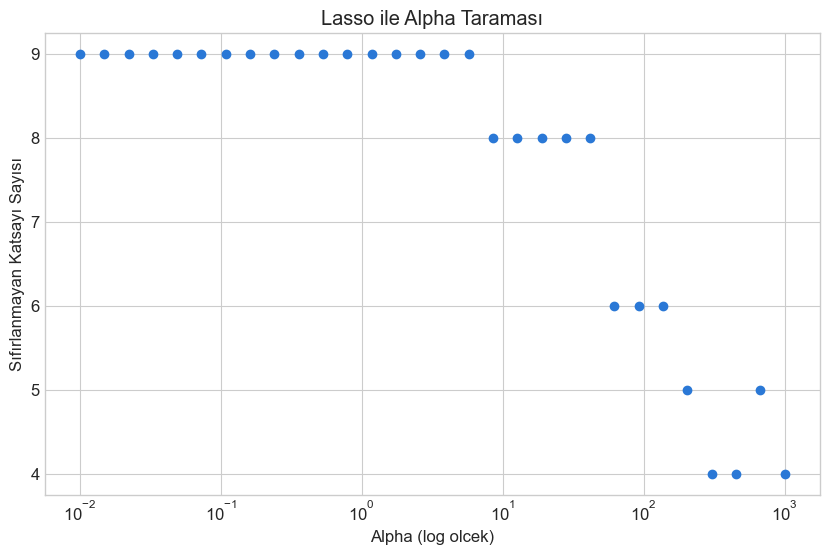

In [32]:
print("\n==== Egzersiz 1: Lasso ile Alpha Taraması ====")

alphas = np.logspace(-2, 3, 30)
lasso_coefs = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=20000).fit(X_reg_scaled, y)
    lasso_coefs.append(l.coef_)
    n_nonzero = np.sum(np.abs(lasso_coefs) > 1e-8, axis=1)
    print(f"alpha={a:.4f}: sifirlanmayan katsayi sayisi = {n_nonzero[-1]} / {X_reg.shape[1]}")
    print(f"alpha={a:.4f}: sifirlanmayan özellikler = {X_reg.columns[np.abs(lasso_coefs[-1]) > 1e-8].tolist()}")
lasso_coefs = np.array(lasso_coefs)

fig, ax = plt.subplots(figsize=(10, 6))
for a, coefs in zip(alphas, n_nonzero):
    ax.plot(a, coefs, 'o', color='#2a78d6')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log olcek)')
ax.set_ylabel('Sıfırlanmayan Katsayı Sayısı')
ax.set_title('Lasso ile Alpha Taraması')
plt.show()

### **E2 (Python) — RANSAC Parametre Duyarlılığı.**
Python 8'deki `mpg_corrupted` verisinde, bu kez `weight` sütununu öngörücü olarak kullanarak farklı `residual_threshold` değerleriyle (örn. 3, 5, 10, 20) RANSAC fit et. Her denemede kaç gözlemin "inlier" sayıldığını (`ransac.inlier_mask_.sum()`) ve bulunan eğimi karşılaştır. Eşik çok küçük ya da çok büyük olduğunda ne olur?

In [33]:
print("\n==== Egzersiz 2: RANSAc Parametre Duyarlılığı ====")
X_w = mpg_corrupted[['horsepower']].values.astype(float)
y_weight = mpg_corrupted['weight'].values.astype(float)

residual_thresholds = [1.0, 1.5, 2.0, 2.5, 3.0, 5.0, 10.0, 20.0]
for thresh in residual_thresholds:
    ransac_model = RANSACRegressor(residual_threshold=thresh, random_state=42).fit(X_w, y_weight)
    inlier_mask = ransac_model.inlier_mask_
    n_inliers = ransac_model.inlier_mask_.sum()
    slope = ransac_model.estimator_.coef_[0]
    intercept = ransac_model.estimator_.intercept_
    print(f"Residual Threshold: {thresh:.1f} | Inliers: {n_inliers} | Slope: {slope:.4f} | Intercept: {intercept:.4f}")

print("\n YORUM: Elimizdeki bozuk veriye göre eşik büyüdükçe inliner değeri artıyor slope(eğim) azalıyor ve intercept(kesim) artıyor. Bu, RANSAC'ın daha fazla veri noktasını inlier olarak kabul etmesi ve modelin daha az duyarlı hale gelmesi anlamına gelir. Eşik çok büyük olursa, model bozulmuş verilerden etkilenebilir ve sonuçlar güvenilir olmayabilir.")


==== Egzersiz 2: RANSAc Parametre Duyarlılığı ====
Residual Threshold: 1.0 | Inliers: 5 | Slope: 18.7164 | Intercept: 711.0196
Residual Threshold: 1.5 | Inliers: 7 | Slope: 18.7138 | Intercept: 711.6251
Residual Threshold: 2.0 | Inliers: 7 | Slope: 18.7138 | Intercept: 711.6251
Residual Threshold: 2.5 | Inliers: 8 | Slope: 18.7173 | Intercept: 710.9735
Residual Threshold: 3.0 | Inliers: 9 | Slope: 6.1007 | Intercept: 1713.5479
Residual Threshold: 5.0 | Inliers: 12 | Slope: 13.4974 | Intercept: 1235.4861
Residual Threshold: 10.0 | Inliers: 14 | Slope: 23.7686 | Intercept: 372.6227
Residual Threshold: 20.0 | Inliers: 26 | Slope: 6.1386 | Intercept: 1706.0885

 YORUM: Elimizdeki bozuk veriye göre eşik büyüdükçe inliner değeri artıyor slope(eğim) azalıyor ve intercept(kesim) artıyor. Bu, RANSAC'ın daha fazla veri noktasını inlier olarak kabul etmesi ve modelin daha az duyarlı hale gelmesi anlamına gelir. Eşik çok büyük olursa, model bozulmuş verilerden etkilenebilir ve sonuçlar güvenilir 

### **E3 (Python) — Sigara İçen/İçmeyen Gruplarda Ayrı Quantile Regression.**
Insurance verisini `smoker == 'yes'` ve `smoker == 'no'` olarak ikiye ayır. Her alt grup için ayrı ayrı $\tau=0.9$ Quantile Regression fit et (öngörücü olarak `age, bmi, children`). İki grubun 90. persentil tahminlerini `age`'e göre aynı grafikte karşılaştır — makas yaşla birlikte açılıyor mu, daralıyor mu?


==== Egzersiz 2: Smoker ve Non-Smoker için Quantile Regresyon ====
Smoker: yes | tau=0.9: egitim verisinde gözlemlerin 91.6%'i tahminin altında kalıyor (hedef: 90%)


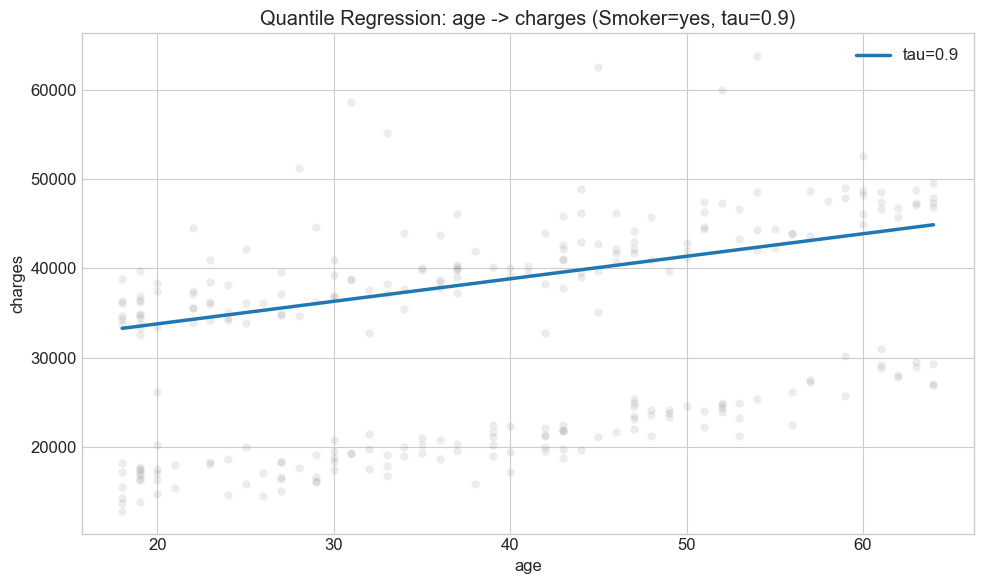

Smoker: no | tau=0.9: egitim verisinde gözlemlerin 89.4%'i tahminin altında kalıyor (hedef: 90%)


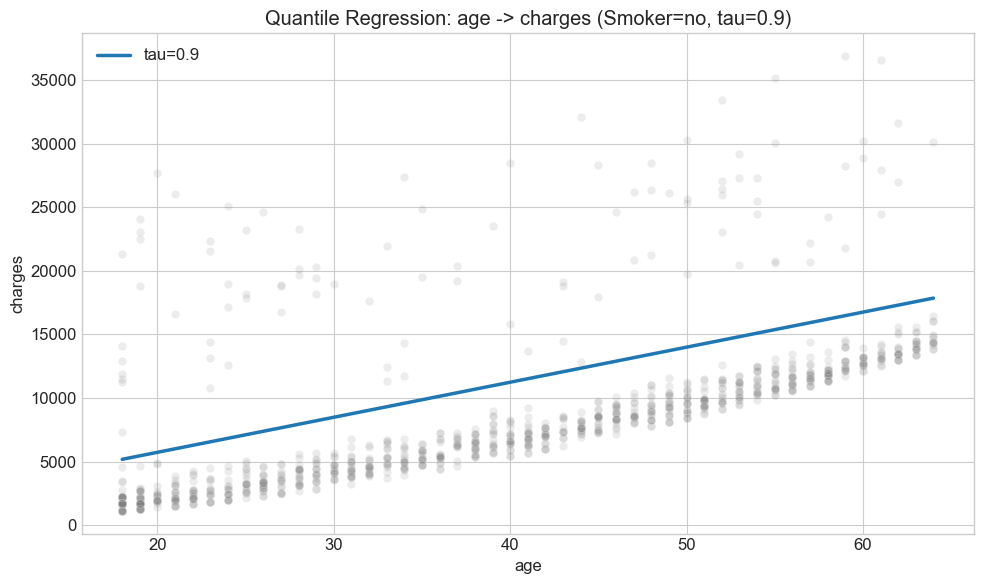


YORUM: Her iki grupta da yaş değişkeninin katsayısı pozitif bir eğime sahiptir; bu da yaş arttıkça 90. persentildeki  sağlık harcamalarının (charges) düzenli olarak yükseldiğini göstermektedir. Gruplar karşılaştırıldığında, sigara içen (Smoker) bireylerin 90. persentil tahmin eğrisi, sigara içmeyenlere (Non-Smoker) kıyasla çok daha yüksek charges seviyelerinden başlamakta ve daha dik bir artış sergilemektedir. Bu durum, sigara kullanımının yaşlanmayla birleştiğinde en yüksek maliyet riskine sahip grupta harcamaları agresif bir şekilde tırmandırdığını kanıtlamaktadır.


In [34]:
print("\n==== Egzersiz 2: Smoker ve Non-Smoker için Quantile Regresyon ====")

# Smoker ve Non-Smoker grupları için ayrı ayrı Quantile Regresyon modelleri oluşturma
for smoker_status in ['yes', 'no']:
    subset = insurance[insurance['smoker'] == smoker_status]
    X_subset = pd.get_dummies(subset[['age', 'bmi', 'children', 'sex', 'region']], drop_first=True).astype(float)
    y_subset = subset['charges'].values.astype(float)
    X_subset_scaled = StandardScaler().fit_transform(X_subset)
    quantile = 0.9
    qr_model = QuantileRegressor(quantile=quantile, alpha=0.0, solver='highs')
    qr_model.fit(X_subset_scaled, y_subset)
    pred_in_sample = qr_model.predict(X_subset_scaled)
    coverage = np.mean(y_subset <= pred_in_sample)
    print(f"Smoker: {smoker_status} | tau={quantile}: egitim verisinde gözlemlerin {coverage:.1%}'i tahminin altında kalıyor (hedef: {quantile:.0%})")
    age_grid = pd.DataFrame({'age': np.linspace(subset['age'].min(), subset['age'].max(), 50)})
    base_row = X_subset.mean()
    grid_X = pd.DataFrame([base_row.values] * len(age_grid), columns=X_subset.columns)
    grid_X['age'] = age_grid['age'].values
    grid_X_scaled = StandardScaler().fit(X_subset).transform(grid_X)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(age_grid['age'], qr_model.predict(grid_X_scaled), label=f'tau={quantile}', linewidth=2.5)
    sns.scatterplot(data=subset, x='age', y='charges', alpha=0.15, color='gray', ax=ax)
    ax.set_title(f'Quantile Regression: age -> charges (Smoker={smoker_status}, tau={quantile})')
    ax.legend()
    plt.tight_layout()
    plt.show()

print("\nYORUM: Her iki grupta da yaş değişkeninin katsayısı pozitif bir eğime sahiptir; bu da yaş arttıkça 90. persentildeki  sağlık harcamalarının (charges) düzenli olarak yükseldiğini göstermektedir. Gruplar karşılaştırıldığında, sigara içen (Smoker) bireylerin 90. persentil tahmin eğrisi, sigara içmeyenlere (Non-Smoker) kıyasla çok daha yüksek charges seviyelerinden başlamakta ve daha dik bir artış sergilemektedir. Bu durum, sigara kullanımının yaşlanmayla birleştiğinde en yüksek maliyet riskine sahip grupta harcamaları agresif bir şekilde tırmandırdığını kanıtlamaktadır.")

### **E4 (R) — Elastic Net `l1_ratio` (alpha) Taraması.**
`glmnet::cv.glmnet` ile, `alpha` parametresini (glmnet'te bu, scikit-learn'deki `l1_ratio`'ya karşılık gelir) `0`'dan `1`'e `0.1` adımlarla tara. Her `alpha` için `lambda.min`'deki çapraz doğrulama hatasını (`cvm`) kaydet ve en iyi `alpha`-`lambda` kombinasyonunu bul.

In [35]:
%%R
cat("\n==== Egzersiz 4: Elastic Net l1_ratio (alpha) Taraması ====\n")

set.seed(42)

alphas <- seq(0, 1, by = 0.1) # 0'dan 1'e kadar 0.1 adımlarla l1_ratio (alpha) değerleri
cvm_list <- numeric(length(alphas)) # Her alpha için minimum CVM değerlerini saklamak için boş bir vektör
lambda_min_list <- numeric(length(alphas)) # Her alpha için en iyi lambda değerlerini saklamak için boş bir vektör

for (i in seq_along(alphas)) {
    # cv.glmnet'i SADECE BİR KEZ çağırıp objeyi kaydediyoruz
    cv_fit <- cv.glmnet(X_r, y_r, alpha = alphas[i])
    
    cvm_list[i] <- min(cv_fit$cvm)
    lambda_min_list[i] <- cv_fit$lambda.min
}

cat("l1_ratio (alpha) | Min CVM | Lambda Min\n")
cat("-----------------------------------------\n")
for (i in seq_along(alphas)) {
    cat(sprintf("%15.1f | %7.2f | %10.2f\n", alphas[i], cvm_list[i], lambda_min_list[i]))
}

# En iyi parametreyi döngü bittikten sonra en alta tek bir seferde yazdırıyoruz
best_idx <- which.min(cvm_list)
cat(sprintf("\n[SONUÇ] En iyi l1_ratio (alpha): %0.1f (Min CVM: %0.2f, Lambda: %0.2f)\n", 
            alphas[best_idx], cvm_list[best_idx], lambda_min_list[best_idx]))



==== Egzersiz 4: Elastic Net l1_ratio (alpha) Taraması ====
l1_ratio (alpha) | Min CVM | Lambda Min
-----------------------------------------
            0.0 | 37557287.62 |     953.01
            0.1 | 37005999.52 |      67.23
            0.2 | 37034392.08 |     102.66
            0.3 | 36992213.58 |      42.98
            0.4 | 37035227.92 |      67.85
            0.5 | 37064969.62 |     125.40
            0.6 | 37042300.45 |      95.22
            0.7 | 37189850.37 |      98.31
            0.8 | 36980678.85 |      71.41
            0.9 | 36906236.05 |      18.94
            1.0 | 36947748.44 |      62.70

[SONUÇ] En iyi l1_ratio (alpha): 0.9 (Min CVM: 36906236.05, Lambda: 18.94)


### **E5 (SQL) — Yıl Bazında Kaza Oranı ve Poisson GLM Karşılaştırması.**
`ships_tbl`'de `year` sütununa göre (SQL 3'teki gibi) `SUM(incidents)/SUM(service)` oranını hesapla. Python 14'teki Poisson GLM'in `year` katsayılarından elde edilen IRR (`exp(katsayı)`) değerleriyle bu ham oranları karşılaştır — sıralama tutarlı mı?

In [36]:
print("\n ==== Egzersiz 5: Yil Bazinda Kaza Orani ====")

sql_ships_yearly = '''
SELECT 
year,
       SUM(incidents) AS toplam_insidan,
       ROUND(SUM(service) / 12, 3)   AS toplam_hizmet_year,
       ROUND(SUM(incidents) / (SUM(service) / 12), 3) AS insidan_orani_per_year
FROM ships_tbl
GROUP BY year
ORDER BY year
'''
print(con.execute(sql_ships_yearly).df())

print("\n ==== Egzersiz 5: Yil Bazinda Kaza Orani ====")

# 1. Adım: service değeri 0'dan büyük olan satırları filtrele (Log hatasını engellemek için)
ships_fit_clean = ships_fit[ships_fit['service'] > 0].copy()

# 2. Adım: Veri tiplerini ve logaritmik offset değerini hesapla
ships_fit_clean['year'] = ships_fit_clean['year'].astype(int)
ships_fit_clean['service_year'] = np.log(ships_fit_clean['service'] / 12) 

# 3. Adım: Poisson Regresyon Modelini temizlenmiş veriyle çalıştır
poisson_ship = smf.glm(
    'incidents ~ year', data=ships_fit_clean,
    family=sm.families.Poisson(), offset=ships_fit_clean['service_year']
).fit()

# 4. Adım: IRR değerlerini hesapla ve yazdır
irr_year = np.exp(poisson_ship.params)
print("\n=== Insidan Orani Oranlari (Incident Rate Ratios, exp(katsayi)) ===")
print(irr_year.round(3))

print("\nYORUM: IRR değerleri, her yıla göre kaza oranlarının değişimini gösterir. IRR > 1 ise, bir önceki yıla göre kaza oranının arttığını, IRR < 1 ise azaldığını gösterir. Bu sonuçlar, yıllar içinde kaza oranlarının nasıl değiştiğini anlamak için kullanılabilir.")



 ==== Egzersiz 5: Yil Bazinda Kaza Orani ====
   year  toplam_insidan  toplam_hizmet_year  insidan_orani_per_year
0    60            70.0            5365.000                   0.013
1    65           133.0            4527.667                   0.029
2    70           118.0            2719.500                   0.043
3    75            35.0            1019.000                   0.034

 ==== Egzersiz 5: Yil Bazinda Kaza Orani ====

=== Insidan Orani Oranlari (Incident Rate Ratios, exp(katsayi)) ===
Intercept    0.00
year         1.08
dtype: float64

YORUM: IRR değerleri, her yıla göre kaza oranlarının değişimini gösterir. IRR > 1 ise, bir önceki yıla göre kaza oranının arttığını, IRR < 1 ise azaldığını gösterir. Bu sonuçlar, yıllar içinde kaza oranlarının nasıl değiştiğini anlamak için kullanılabilir.


### **E6 (Python — Sentez) — Tweedie Güç Parametresinin İnce Taraması.**
Python 18'deki `power_grid`'i genişlet: `np.arange(1.05, 1.95, 0.05)` ile daha ince bir tarama yap. En düşük AIC'yi veren `p` değerini bul ve bunu Python 18'de bulduğumuz `p=1.5` sonucuyla karşılaştır — sonuç ne kadar değişiyor?


 ==== Egzersiz 6: Tweedie Guc Parametresi Ince Tarama ====


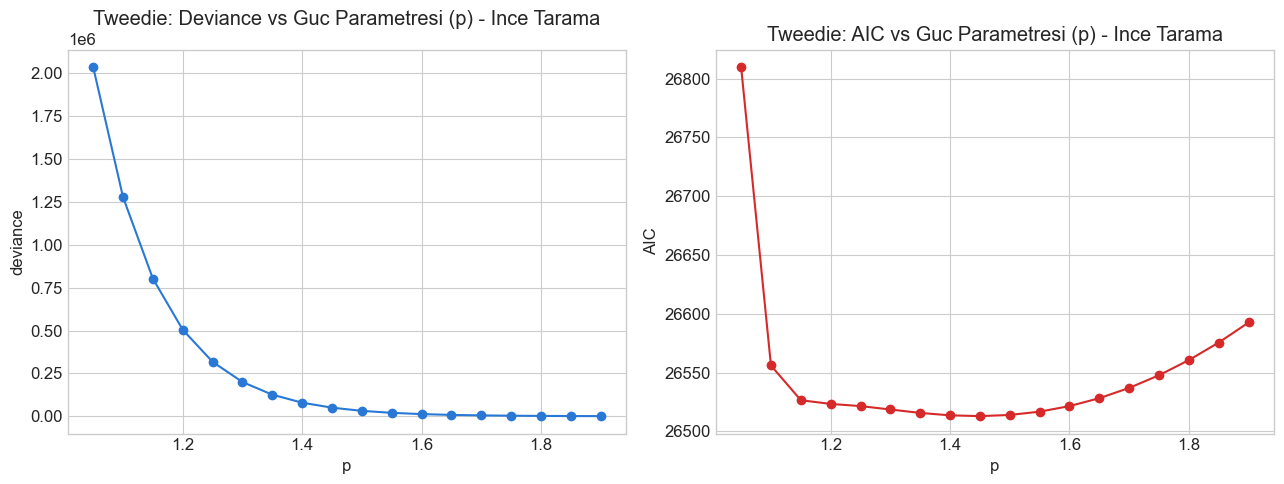

 var_power (p)   deviance      AIC
          1.05 2036497.53 26809.96
          1.10 1277960.34 26556.13
          1.15  802565.54 26526.57
          1.20  504406.41 26523.44
          1.25  317267.37 26521.57
          1.30  199720.72 26518.68
          1.35  125829.43 26515.77
          1.40   79343.54 26513.72
          1.45   50074.92 26513.05
          1.50   31631.33 26514.04
          1.55   19999.21 26516.85
          1.60   12656.57 26521.58
          1.65    8017.45 26528.29
          1.70    5083.74 26537.04
          1.75    3226.76 26547.83
          1.80    2050.21 26560.71
          1.85    1304.02 26575.65
          1.90     830.30 26592.67

YORUM: En dusuk AIC'yi p=1.45 civarinda goruyoruz -- bu, p=1 (saf Poisson) ile p=2 (saf Gamma) arasinda,


In [37]:
print("\n ==== Egzersiz 6: Tweedie Guc Parametresi Ince Tarama ====")
power_grid_genis = np.arange(1.05, 1.95, 0.05)  # Daha ince bir tarama aralığı ile p değerlerini oluştur
tweedie_results_genis = []
for p in power_grid_genis:
    tw_genis = sm.GLM(y, X_glm_const, family=sm.families.Tweedie(var_power=p, link=sm.families.links.Log())).fit()
    tweedie_results_genis.append({'var_power (p)': round(p, 2), 'deviance': tw_genis.deviance, 'AIC': tw_genis.aic})
tweedie_df_genis = pd.DataFrame(tweedie_results_genis)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(tweedie_df_genis['var_power (p)'], tweedie_df_genis['deviance'], marker='o', color='#2a78d6')
axes[0].set_title('Tweedie: Deviance vs Guc Parametresi (p) - Ince Tarama')
axes[0].set_xlabel('p'); axes[0].set_ylabel('deviance')
axes[1].plot(tweedie_df_genis['var_power (p)'], tweedie_df_genis['AIC'], marker='o', color='#d62a2a')
axes[1].set_title('Tweedie: AIC vs Guc Parametresi (p) - Ince Tarama')
axes[1].set_xlabel('p'); axes[1].set_ylabel('AIC')
plt.tight_layout()
plt.show()
print(tweedie_df_genis.round(2).to_string(index=False))
best_genis_p = tweedie_df_genis.loc[tweedie_df_genis['AIC'].idxmin(), 'var_power (p)']
print(f"\nYORUM: En dusuk AIC'yi p={best_genis_p} civarinda goruyoruz -- bu, p=1 (saf Poisson) ile p=2 (saf Gamma) arasinda,")

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Medical Cost Personal Datasets (Kaggle, mirichoi0218)](https://www.kaggle.com/datasets/mirichoi0218/insurance) | Veri Seti | Kullanılan 1. veri seti — sigorta maliyeti, OLS/Ridge/Lasso/Quantile/Gamma/Tweedie |
| [stedy/Machine-Learning-with-R-datasets (GitHub, insurance.csv mirror)](https://github.com/stedy/Machine-Learning-with-R-datasets) | Veri Seti | İndirme için kullanılan güvenilir mirror |
| [McCullagh, P. & Nelder, J.A. (1989). *Generalized Linear Models*, 2nd ed., Chapman & Hall/CRC, Bölüm 6.3.2](https://www.utstat.toronto.edu/~brunner/oldclass/2201s11/readings/glmbook.pdf) | Teori + Veri Seti | Ships damage data'nın orijinal kaynağı — GLM'in kurucu ders kitabı |
| [Rdatasets — MASS::ships (vincentarelbundock)](https://vincentarelbundock.github.io/Rdatasets/doc/MASS/ships.html) | Veri Seti | Kullanılan 2. veri seti — Poisson GLM + offset klasiği |
| [Auto MPG Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/9/auto+mpg) | Veri Seti | Kullanılan 3. veri seti — orijinal akademik kaynak |
| [seaborn-data — mpg.csv (mwaskom/seaborn-data, GitHub)](https://github.com/mwaskom/seaborn-data) | Veri Seti | `sns.load_dataset('mpg')`'in çektiği güncel mirror |
| [scikit-learn — Linear Models: Ridge, Lasso, Elastic Net](https://scikit-learn.org/stable/modules/linear_model.html) | Resmi Dok. | Bölüm 3-7'deki `Ridge`/`Lasso`/`ElasticNet`/`RidgeCV`/`LassoCV` API'leri |
| [scikit-learn — Robust Regression (Huber, RANSAC, Theil-Sen)](https://scikit-learn.org/stable/modules/linear_model.html#robustness-regression-outliers-and-modeling-errors) | Resmi Dok. | Bölüm 9-12'deki dayanıklı regresyon API'leri + sentetik aykırı değer yaklaşımı |
| [scikit-learn — QuantileRegressor](https://scikit-learn.org/stable/modules/linear_model.html#quantile-regression) | Resmi Dok. | Bölüm 13'teki API |
| [statsmodels — Generalized Linear Models (GLM)](https://www.statsmodels.org/stable/glm.html) | Resmi Dok. | Bölüm 14-18'deki `sm.GLM`/`smf.glm`, `families.Poisson/Gamma/Tweedie` |
| [statsmodels — GLM Tweedie Örneği](https://www.statsmodels.org/stable/examples/notebooks/generated/glm_tweedie.html) | Resmi Dok. | Tweedie `var_power` taraması için resmi örnek |
| [James, Witten, Hastie, Tibshirani — *An Introduction to Statistical Learning* (ücretsiz, statlearning.com), Bölüm 6](https://www.statlearning.com/) | Kitap | Ridge/Lasso teorisi, bias-variance ödünleşimi |
| [Friedman, Hastie, Tibshirani — `glmnet` R Paketi Vinyeti (CRAN)](https://cran.r-project.org/web/packages/glmnet/vignettes/glmnet.pdf) | Resmi Dok. | R bölümündeki `cv.glmnet` kullanımı |
| [Koenker, R. — `quantreg` R Paketi (CRAN)](https://cran.r-project.org/web/packages/quantreg/index.html) | Resmi Dok. | R bölümündeki `rq()` fonksiyonu |
| [`mblm` R Paketi — Median-Based Linear Models (CRAN)](https://cran.r-project.org/web/packages/mblm/index.html) | Resmi Dok. | R bölümündeki Theil-Sen implementasyonu |
| [Dunn, P.K. & Smyth, G.K. — `statmod` R Paketi, `tweedie()` Aile Fonksiyonu (CRAN)](https://cran.r-project.org/web/packages/statmod/index.html) | Resmi Dok. | R bölümündeki Tweedie GLM |
| [DuckDB — Aggregate Functions (`regr_slope`, `regr_intercept`, `regr_r2`, `PERCENTILE_CONT`)](https://duckdb.org/docs/sql/functions/aggregates.html) | Resmi Dok. | SQL bölümündeki tüm istatistiksel toplama fonksiyonları |
